## Data Preprocessing Experiment

주어진 데이터에 대해 다양한 전처리를 시도하고, 가장 적절한 전처리 방식을 채택

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, confusion_matrix, accuracy_score, roc_auc_score
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras import optimizers
import tensorflow as tf
from tensorflow.keras import backend as k
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Dropout, Dense

/Users/wheemin/Desktop/my_project/KAMP_AI제조데이터분석/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### 0.Before train/test split

In [2]:
labeled_cn7 = pd.read_csv('../data/1. 사출성형기 AI 데이터셋/moldset_labeled_cn7.csv', index_col=0)
labeled_rg3 = pd.read_csv('../data/1. 사출성형기 AI 데이터셋/moldset_labeled_rg3.csv', index_col=0)
unlabeled_cn7 = pd.read_csv('../data/1. 사출성형기 AI 데이터셋/moldset_unlabeled_cn7.csv', index_col=0)
unlabeled_rg3 = pd.read_csv('../data/1. 사출성형기 AI 데이터셋/moldset_unlabeled_rg3.csv', index_col=0)

#### 0_1. Scaling 여부 확인

In [14]:
print('####### labeled_cn7 #######')
print('mean of each column')
print(labeled_cn7.iloc[:,1:].mean(axis=0).values)
print('standard deviation of each column')
print(labeled_cn7.iloc[:,1:].std(axis=0).values)

print('####### unlabeled_cn7 #######')
print('mean of each column')
print(unlabeled_cn7.mean(axis=0).values)
print('standard deviation of each column')
print(unlabeled_cn7.std(axis=0).values)

####### labeled_cn7 #######
mean of each column
[-2.95717208e-14 -5.35107329e-15  6.47761503e-15  5.06943785e-14
 -1.57481148e-14  4.63053249e-12 -3.62840320e-14  0.00000000e+00
  3.23880752e-15 -6.68884161e-15  4.19636800e-14  1.07490858e-13
 -1.59241370e-14 -3.75513915e-15 -3.70819991e-15 -1.82476293e-14
 -3.50548107e-14  8.74536703e-15  2.11431936e-14  5.25719481e-15
 -3.57941037e-14 -2.67553664e-15 -8.21436689e-16 -1.64287338e-16]
standard deviation of each column
[1.00041314 1.00041314 1.00041314 1.00041314 1.00041314 1.00041314
 1.00041314 0.         1.00041314 1.00041314 1.00041314 1.00041314
 1.00041314 1.00041314 1.00041314 1.00041314 1.00041314 1.00041314
 1.00041314 1.00041314 1.00041314 1.00041314 1.00041314 1.00041314]
####### unlabeled_cn7 #######
mean of each column
[ 1.03237288e-16 -7.67827333e-16  2.58093221e-17  6.32328392e-16
 -9.03326274e-17 -1.67760594e-16 -9.03326274e-17  1.38725106e-15
 -1.54855933e-16  3.09711865e-16  2.32283899e-16 -3.22616526e-16
 -1.80665255e

In [15]:
total_cn7 = pd.concat([labeled_cn7.iloc[:,1:], unlabeled_cn7], axis=0)
print('####### total_cn7 #######')
print('mean of each column')
print(total_cn7.mean(axis=0).values)
print('standard deviation of each column')
print(total_cn7.std(axis=0).values)

####### total_cn7 #######
mean of each column
[-9.48170059e-16 -9.23218216e-16  2.12090671e-16  2.28309370e-15
 -6.23796092e-16  1.53715833e-13 -1.23511626e-15  1.30997179e-15
 -3.74277655e-17  2.49518437e-17  1.59691799e-15  3.25621560e-15
 -6.98651623e-16 -3.86753577e-16 -9.98073747e-17 -3.86753577e-16
  3.38097482e-15  2.49518437e-17  1.02302559e-14  1.58444207e-15
 -1.95871973e-15 -5.11512795e-16 -7.48555310e-17  4.99036873e-17]
standard deviation of each column
[1.00001372 1.00001372 1.00001372 1.00001372 1.00001372 1.00001372
 1.00001372 0.98326137 1.00001372 1.00001372 1.00001372 1.00001372
 1.00001372 1.00001372 1.00001372 1.00001372 1.00001372 1.00001372
 1.00001372 1.00001372 1.00001372 1.00001372 1.00001372 1.00001372]


In [16]:
total_rg3 = pd.concat([labeled_rg3.iloc[:,1:], unlabeled_rg3], axis=0)
print('####### labeled_rg3 #######')
print('mean of each column')
print(labeled_rg3.iloc[:,1:].mean(axis=0).values)
print('standard deviation of each column')
print(labeled_rg3.iloc[:,1:].std(axis=0).values)

print('####### unlabeled_rg3 #######')
print('mean of each column')
print(unlabeled_rg3.mean(axis=0).values)
print('standard deviation of each column')
print(unlabeled_rg3.std(axis=0).values)

print('####### total_rg3 #######')
print('mean of each column')
print(total_rg3.mean(axis=0).values)
print('standard deviation of each column')
print(total_rg3.std(axis=0).values)

####### labeled_rg3 #######
mean of each column
[-4.71531068e-14 -1.92363516e-16 -1.76012617e-14  5.50264853e-14
  4.97259688e-14  2.78888625e-12  1.81326659e-13  0.00000000e+00
 -2.75560736e-14 -1.20693078e-14 -8.43273562e-14 -7.25210454e-14
 -1.16139473e-14  6.58845041e-15  8.12735853e-15 -4.46230757e-14
  4.47365401e-14  2.13027565e-14  4.06878892e-14 -7.98969839e-14
 -2.17491000e-14 -6.39608689e-15 -3.84727031e-16  4.80908789e-17]
standard deviation of each column
[1.00042328 1.00042328 1.00042328 1.00042328 1.00042328 1.00042328
 1.00042328 0.         1.00042328 1.00042328 1.00042328 1.00042328
 1.00042328 1.00042328 1.00042328 1.00042328 1.00042328 1.00042328
 1.00042328 1.00042328 1.00042328 1.00042328 1.00042328 1.00042328]
####### unlabeled_rg3 #######
mean of each column
[ 1.89789106e-16  1.77136499e-16  6.32630354e-17  1.39178678e-16
 -5.31409497e-16 -1.01220857e-16  1.64483892e-16  7.59156425e-17
  0.00000000e+00 -1.20199767e-16 -2.53052142e-17  2.15094320e-16
 -3.28967784e

In [ ]:
# Max_Injection_Speed, 평균이 정확히 0
unlabeled_rg3.iloc[:,8]

119515   -1.203070
119547   -1.200666
119618   -1.200666
119781   -1.193454
120044   -1.159797
            ...   
795299    0.946132
795303    0.948536
795304    0.948536
795308    0.948536
795309    0.948536
Name: Max_Injection_Speed, Length: 35941, dtype: float64

#### 0_2. Merge duplicated rows

**CN7**

In [ ]:
print('number of rows labeled_cn7:', labeled_cn7.shape[0])
n_duplicated = labeled_cn7.duplicated(keep=False).sum()
print('number of duplicated rows in labeled_cn7:', n_duplicated)
print('number of unique rows in labeled_cn7:', labeled_cn7.shape[0] - n_duplicated)
labeled_cn7[labeled_cn7.duplicated(keep=False)] # check if duplicated rows are next to each other

number of rows labeled_cn7: 1211
number of duplicated rows in labeled_cn7: 1188
number of unique rows in labeled_cn7: 23


,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
1,0,2.080358,1.894372,-0.527100,1.886261,0.978580,-0.711164,1.471608,0.0,-1.347095,...,-0.533773,0.056153,0.622557,0.914107,0.504051,-0.915098,-2.263700,-0.874018,1.023094,1.337339
2,0,2.080358,1.894372,-0.527100,1.886261,0.978580,-0.711164,1.471608,0.0,-1.347095,...,-0.533773,0.056153,0.622557,0.914107,0.504051,-0.915098,-2.263700,-0.874018,1.023094,1.337339
3,0,1.679123,1.894372,-0.527100,1.377857,0.978580,1.202502,1.471608,0.0,-1.347095,...,-0.533773,0.729073,-0.765355,1.231418,0.886706,-0.299626,0.013158,-1.176164,1.166162,1.337339
4,0,1.679123,1.894372,-0.527100,1.377857,0.978580,1.202502,1.471608,0.0,-1.347095,...,-0.533773,0.729073,-0.765355,1.231418,0.886706,-0.299626,0.013158,-1.176164,1.166162,1.337339
5,0,1.277888,1.088442,-0.576184,1.886261,0.978580,-0.711164,1.471608,0.0,-0.763018,...,-0.152634,0.280414,0.067358,0.596893,1.269321,0.008133,0.013158,-0.571865,1.166162,1.337339
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1206,0,-1.931915,-1.732320,5.608208,-1.164166,-0.902466,-0.711164,-1.185844,0.0,2.352070,...,-0.914898,0.280414,0.067358,1.548728,1.014257,0.623605,0.923887,0.737456,0.093154,-0.155625
1207,0,-4.740484,-4.553063,9.829303,-1.672571,-0.902466,3.116169,-1.487849,0.0,5.467151,...,-3.201688,-0.841164,1.177755,-0.989563,1.779489,0.315892,0.013158,1.442471,0.093154,-0.205391
1208,0,-4.740484,-4.553063,9.829303,-1.672571,-0.902466,3.116169,-1.487849,0.0,5.467151,...,-3.201688,-0.841164,1.177755,-0.989563,1.779489,0.315892,0.013158,1.442471,0.093154,-0.205391
1209,0,-7.549091,-7.776799,20.038456,-3.706092,-0.902466,6.943503,-2.876962,0.0,8.776929,...,-6.631852,0.056153,-0.765355,0.914107,1.651976,-0.299626,2.290016,1.442471,0.093154,-0.205391


In [31]:
print('number of rows unlabeled_cn7:', unlabeled_cn7.shape[0])
n_duplicated = unlabeled_cn7.duplicated(keep=False).sum()
print('number of duplicated rows in unlabeled_cn7:', n_duplicated)
print('number of unique rows in unlabeled_cn7:', unlabeled_cn7.shape[0] - n_duplicated)
unlabeled_cn7[unlabeled_cn7.duplicated(keep=False)] # check if duplicated rows are next to each other

number of rows unlabeled_cn7: 35239
number of duplicated rows in unlabeled_cn7: 12936
number of unique rows in unlabeled_cn7: 22303


,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
148671,1.311584,-2.898344,0.920799,1.530173,1.019822,1.030828,0.898597,0.828102,2.827678,1.025136,...,-0.448714,1.019488,0.919876,0.930598,0.719631,2.060829,1.041659,-0.519495,0.973897,0.833700
148672,1.311584,-2.898344,0.920799,1.530173,1.019822,1.030828,0.898597,0.828102,2.827678,1.025136,...,-0.448714,1.019488,0.919876,0.930598,0.719631,2.060829,1.041659,-0.519495,0.973897,0.833700
149627,1.338018,-2.785047,1.107168,1.537166,1.019822,1.030671,0.923329,0.828102,2.675358,1.031627,...,0.874772,1.025349,0.908420,1.000780,0.587458,2.255039,1.058077,-0.535530,0.880699,0.693966
149628,1.338018,-2.785047,1.107168,1.537166,1.019822,1.030671,0.923329,0.828102,2.675358,1.031627,...,0.874772,1.025349,0.908420,1.000780,0.587458,2.255039,1.058077,-0.535530,0.880699,0.693966
149994,1.311584,-2.898344,1.070168,1.527065,1.019822,1.030702,0.890353,0.828102,2.751518,1.025136,...,0.885032,1.020953,0.828224,0.888489,0.521371,2.216197,1.008823,-0.503460,0.857399,0.893586
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777212,1.042839,-0.632400,1.145538,0.850320,1.039711,1.030167,1.050425,0.828102,1.008295,1.038118,...,1.086804,1.054652,0.896963,0.986743,0.818761,0.254672,-0.583724,1.035942,0.872932,0.700620
777215,1.011999,-0.745697,1.263389,0.848766,1.039711,1.030230,1.046990,0.828102,1.143691,1.044609,...,1.066284,1.050989,0.942789,0.874453,0.917890,0.235251,-0.616560,1.148190,0.872932,0.693966
777216,1.011999,-0.745697,1.263389,0.848766,1.039711,1.030230,1.046990,0.828102,1.143691,1.044609,...,1.066284,1.050989,0.942789,0.874453,0.917890,0.235251,-0.616560,1.148190,0.872932,0.693966
777219,0.981159,-0.875180,1.548424,0.842550,1.039711,1.030293,1.031189,0.828102,1.287549,1.057592,...,1.035506,1.053919,0.862594,0.958671,0.901369,0.196409,-0.534470,1.148190,0.872932,0.693966


In [48]:
# 모든 열이 동일한 경우 : 병합
labeled_without_duplicates_cn7 = labeled_cn7.drop_duplicates()
print('shape of labeled_without_duplicates (cn7):', labeled_without_duplicates_cn7.shape)

print('number of rows with the same feature values but different labels (cn7):')
print(labeled_without_duplicates_cn7.iloc[:,1:].duplicated(keep=False).sum())

# 모든 피처값이 동일하지만 레이블이 다른 경우 (11개) : 불량품으로 간주
outliers_indices = labeled_without_duplicates_cn7[labeled_without_duplicates_cn7.iloc[:,1:].duplicated(keep='first')].index
print('number of rows with the same feature values but different labels (cn7):', len(outliers_indices))
print('###before adjustment###')
display(labeled_without_duplicates_cn7.loc[outliers_indices, :])
print('###after adjustment###')
labeled_without_duplicates_cn7.loc[outliers_indices, 'PassOrFail'] = 1
display(labeled_without_duplicates_cn7.loc[outliers_indices, :])

print('shape oflabeled_without_duplicates (cn7):', labeled_without_duplicates_cn7.shape)

shape of labeled_without_duplicates (cn7): (617, 25)
number of rows with the same feature values but different labels (cn7):
22
number of rows with the same feature values but different labels (cn7): 11
###before adjustment###


,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
48,0,1.277888,1.491397,-0.625267,0.361047,0.978580,-0.711164,1.471608,0.0,-1.152398,...,-0.152634,-0.168176,-0.210156,0.279582,1.269321,0.623605,0.923887,-0.269711,1.166162,1.287574
80,1,2.080358,1.894372,-0.478017,0.361047,0.978580,-0.711164,1.471608,0.0,-1.347095,...,-0.533773,-0.392505,0.900156,-0.037728,-0.388733,1.546836,0.923887,-1.276879,1.309231,1.387105
96,0,1.679123,1.894372,-0.330766,0.361047,0.978580,1.202502,1.471608,0.0,-1.347095,...,-0.914898,-0.168176,2.843181,0.596893,-0.516285,-2.761513,1.834616,0.435303,1.309231,1.387105
100,0,1.679123,1.491397,-0.428933,1.377857,0.978580,-0.711164,1.471608,0.0,-0.957708,...,-0.533773,-1.065425,0.344957,-1.941496,0.631602,0.315892,-1.352970,-0.773295,1.237697,1.387105
102,0,1.277888,1.491397,-0.428933,1.377857,0.978580,-0.711164,1.471608,0.0,-0.957708,...,-0.533773,1.177731,-1.320553,0.279582,1.141770,0.315892,-1.352970,-1.075448,1.309231,1.387105
104,0,0.876653,1.088442,-0.576184,0.361047,0.978580,-0.711164,1.532018,0.0,-0.957708,...,-0.533773,0.953402,-0.210156,0.279582,1.269321,-0.915098,0.468557,-0.168996,1.237697,1.387105
106,0,0.876653,1.088442,-0.478017,0.361047,0.978580,-0.711164,1.471608,0.0,-0.957708,...,-0.914898,-0.616835,-1.042954,1.866039,0.759154,1.239076,1.379287,-0.974733,1.237697,1.387105
108,0,0.475456,0.282513,-0.478017,0.361047,0.978580,-0.711164,1.471608,0.0,-0.373631,...,-1.677161,-2.187003,-1.598068,-2.258806,0.121435,-0.915098,0.468557,-0.571865,1.166162,1.337339
110,0,0.475456,0.685468,-0.478017,0.361047,2.859537,-0.711164,1.471608,0.0,-0.373631,...,-1.296037,0.056153,-0.210156,0.596893,-0.516285,0.315892,1.834616,-0.974733,1.023094,1.287574
112,0,1.277888,1.088442,-0.330766,0.361047,2.859537,-0.711164,1.592429,0.0,-0.957708,...,-1.296037,2.074980,0.067358,0.279582,-1.154004,0.931364,-0.897571,-0.269711,1.166162,1.387105


###after adjustment###


,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
48,1,1.277888,1.491397,-0.625267,0.361047,0.978580,-0.711164,1.471608,0.0,-1.152398,...,-0.152634,-0.168176,-0.210156,0.279582,1.269321,0.623605,0.923887,-0.269711,1.166162,1.287574
80,1,2.080358,1.894372,-0.478017,0.361047,0.978580,-0.711164,1.471608,0.0,-1.347095,...,-0.533773,-0.392505,0.900156,-0.037728,-0.388733,1.546836,0.923887,-1.276879,1.309231,1.387105
96,1,1.679123,1.894372,-0.330766,0.361047,0.978580,1.202502,1.471608,0.0,-1.347095,...,-0.914898,-0.168176,2.843181,0.596893,-0.516285,-2.761513,1.834616,0.435303,1.309231,1.387105
100,1,1.679123,1.491397,-0.428933,1.377857,0.978580,-0.711164,1.471608,0.0,-0.957708,...,-0.533773,-1.065425,0.344957,-1.941496,0.631602,0.315892,-1.352970,-0.773295,1.237697,1.387105
102,1,1.277888,1.491397,-0.428933,1.377857,0.978580,-0.711164,1.471608,0.0,-0.957708,...,-0.533773,1.177731,-1.320553,0.279582,1.141770,0.315892,-1.352970,-1.075448,1.309231,1.387105
104,1,0.876653,1.088442,-0.576184,0.361047,0.978580,-0.711164,1.532018,0.0,-0.957708,...,-0.533773,0.953402,-0.210156,0.279582,1.269321,-0.915098,0.468557,-0.168996,1.237697,1.387105
106,1,0.876653,1.088442,-0.478017,0.361047,0.978580,-0.711164,1.471608,0.0,-0.957708,...,-0.914898,-0.616835,-1.042954,1.866039,0.759154,1.239076,1.379287,-0.974733,1.237697,1.387105
108,1,0.475456,0.282513,-0.478017,0.361047,0.978580,-0.711164,1.471608,0.0,-0.373631,...,-1.677161,-2.187003,-1.598068,-2.258806,0.121435,-0.915098,0.468557,-0.571865,1.166162,1.337339
110,1,0.475456,0.685468,-0.478017,0.361047,2.859537,-0.711164,1.471608,0.0,-0.373631,...,-1.296037,0.056153,-0.210156,0.596893,-0.516285,0.315892,1.834616,-0.974733,1.023094,1.287574
112,1,1.277888,1.088442,-0.330766,0.361047,2.859537,-0.711164,1.592429,0.0,-0.957708,...,-1.296037,2.074980,0.067358,0.279582,-1.154004,0.931364,-0.897571,-0.269711,1.166162,1.387105


shape oflabeled_without_duplicates (cn7): (617, 25)


In [ ]:
# unlabeled_cn7에는 레이블이 없으므로 모든 열이 동일한 경우 : 병합
# 22303+(12936/2) = 28871
unlabeled_without_duplicates_cn7 = unlabeled_cn7.drop_duplicates()
print('shape of unlabeled_without_duplicates (cn7):', unlabeled_without_duplicates_cn7.shape)

shape of unlabeled_without_duplicates (cn7): (28771, 24)


**RG3**

In [51]:
# rg3도 똑같은 규칙 적용
print('number of rows labeled_rg3:', labeled_rg3.shape[0])
n_duplicated = labeled_rg3.duplicated(keep=False).sum()
print('number of duplicated rows in labeled_rg3:', n_duplicated)
print('number of unique rows in labeled_rg3:', labeled_rg3.shape[0] - n_duplicated)
labeled_rg3[labeled_rg3.duplicated(keep=False)]

number of rows labeled_rg3: 1182
number of duplicated rows in labeled_rg3: 1132
number of unique rows in labeled_rg3: 50


,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
1211,0,-0.029099,-1.192531,1.977737,0.249511,1.033078,2.867608,-1.755816,0.0,2.187583,...,-1.306878,0.096629,-0.496175,-0.002081,0.047749,0.282727,-0.354184,0.183232,-1.393485,-1.576042
1212,0,-0.029099,-1.192531,1.977737,0.249511,1.033078,2.867608,-1.755816,0.0,2.187583,...,-1.306878,0.096629,-0.496175,-0.002081,0.047749,0.282727,-0.354184,0.183232,-1.393485,-1.576042
1213,0,-0.029099,-1.192531,1.528778,0.249511,1.033078,2.075089,-0.192928,0.0,2.187583,...,-0.841877,0.562844,1.442567,-0.002081,0.340262,1.850096,-0.851297,0.183232,-1.535968,-1.576042
1214,0,-0.029099,-1.192531,1.528778,0.249511,1.033078,2.075089,-0.192928,0.0,2.187583,...,-0.841877,0.562844,1.442567,-0.002081,0.340262,1.850096,-0.851297,0.183232,-1.535968,-1.576042
1215,0,-0.029099,-1.192531,0.630880,-0.298708,1.033078,1.277707,-1.755816,0.0,1.402554,...,-1.539374,1.262095,-0.253813,-0.002081,0.925242,0.282727,-1.348485,0.284910,-1.535968,-1.576042
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2388,0,-0.029099,0.838552,-1.164915,-0.298708,-0.386790,-1.114437,0.588367,0.0,-0.952293,...,1.715615,1.028988,-0.011452,-0.002081,0.925242,0.282727,1.634495,-0.020131,1.598652,1.701543
2389,0,-0.029099,0.838552,-1.613854,-0.846822,-1.806725,-1.114437,1.369662,0.0,-1.737322,...,1.483119,1.728310,-0.253813,-0.002081,0.925242,-0.971148,-1.348485,-0.020131,1.456169,1.701543
2390,0,-0.029099,0.838552,-1.613854,-0.846822,-1.806725,-1.114437,1.369662,0.0,-1.737322,...,1.483119,1.728310,-0.253813,-0.002081,0.925242,-0.971148,-1.348485,-0.020131,1.456169,1.701543
2391,0,-0.029099,0.838552,-0.491498,-1.395040,-0.386790,-0.317055,1.369662,0.0,-0.952293,...,1.483119,-1.535053,1.442567,-0.616737,0.486518,-0.030765,-0.851297,-0.121809,1.456169,1.701543


In [53]:
print('number of rows unlabeled_rg3:', unlabeled_rg3.shape[0])
n_duplicated = unlabeled_rg3.duplicated(keep=False).sum()
print('number of duplicated rows in unlabeled_rg3:', n_duplicated)
print('number of unique rows in unlabeled_rg3:', unlabeled_rg3.shape[0] - n_duplicated)
unlabeled_rg3[unlabeled_rg3.duplicated(keep=False)] # check if duplicated rows are next to each other

number of rows unlabeled_rg3: 35941
number of duplicated rows in unlabeled_rg3: 12468
number of unique rows in unlabeled_rg3: 23473


,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
131314,-0.834898,-0.862066,0.439610,0.994172,0.822556,0.759455,0.593574,-0.798458,0.910071,0.505703,...,0.688609,0.810153,0.877664,0.864812,0.581814,0.515617,-0.208725,0.067378,0.378696,0.245957
131315,-0.834898,-0.862066,0.439610,0.994172,0.822556,0.759455,0.593574,-0.798458,0.910071,0.505703,...,0.688609,0.810153,0.877664,0.864812,0.581814,0.515617,-0.208725,0.067378,0.378696,0.245957
132742,-0.789278,-0.792756,0.473446,0.989437,0.785427,0.759488,0.596124,-0.798458,0.549467,0.500215,...,0.637166,0.811637,0.893111,0.840263,0.592095,0.685691,-0.085013,0.017256,0.613974,0.453983
132743,-0.789278,-0.792756,0.473446,0.989437,0.785427,0.759488,0.596124,-0.798458,0.549467,0.500215,...,0.637166,0.811637,0.893111,0.840263,0.592095,0.685691,-0.085013,0.017256,0.613974,0.453983
132854,-0.834898,-0.857115,0.439610,0.991015,0.785427,0.759423,0.597398,-0.798458,0.907667,0.500215,...,0.703740,0.813863,0.916280,0.832080,0.571532,0.564210,-0.229344,0.037305,0.640116,0.468842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795299,-0.824371,-0.842263,0.484725,0.607490,0.841121,0.759325,0.642011,-0.798458,0.946132,0.511191,...,0.697688,0.818315,0.854495,0.872996,0.550970,0.782877,-0.167488,0.698913,0.744684,0.610002
795303,-0.824371,-0.842263,0.479891,0.607490,0.841121,0.759325,0.642011,-0.798458,0.948536,0.516679,...,0.706766,0.815347,0.931726,0.864812,0.674347,0.661395,-0.085013,0.698913,0.753398,0.610002
795304,-0.824371,-0.842263,0.479891,0.607490,0.841121,0.759325,0.642011,-0.798458,0.948536,0.516679,...,0.706766,0.815347,0.931726,0.864812,0.674347,0.661395,-0.085013,0.698913,0.753398,0.610002
795308,-0.824371,-0.842263,0.478280,0.605911,0.841121,0.759325,0.642011,-0.798458,0.948536,0.516679,...,0.709792,0.809411,0.885388,0.840263,0.715472,0.637099,-0.146869,0.658816,0.753398,0.610002


In [55]:
# 모든 열이 동일한 경우 : 병합
labeled_without_duplicates_rg3 = labeled_rg3.drop_duplicates()
print('shape of labeled_without_duplicates (rg3):', labeled_without_duplicates_rg3.shape)

print('number of rows with the same feature values but different labels (rg3):')
print(labeled_without_duplicates_rg3.iloc[:,1:].duplicated(keep=False).sum())

# 모든 피처값이 동일하지만 레이블이 다른 경우 (11개) : 불량품으로 간주
outliers_indices = labeled_without_duplicates_rg3[labeled_without_duplicates_rg3.iloc[:,1:].duplicated(keep='first')].index
print('number of rows with the same feature values but different labels (rg3):', len(outliers_indices))
print('###before adjustment###')
display(labeled_without_duplicates_rg3.loc[outliers_indices, :])
print('###after adjustment###')
labeled_without_duplicates_rg3.loc[outliers_indices, 'PassOrFail'] = 1
display(labeled_without_duplicates_rg3.loc[outliers_indices, :])

print('shape of labeled_without_duplicates (rg3):', labeled_without_duplicates_rg3.shape)

shape of labeled_without_duplicates (rg3): (616, 25)
number of rows with the same feature values but different labels (rg3):
50
number of rows with the same feature values but different labels (rg3): 25
###before adjustment###


,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
1348,0,-0.029099,-1.192531,-0.042538,0.249511,-0.386790,0.480326,-0.192928,0.0,0.617645,...,-1.074373,0.562844,-1.950268,0.919808,-0.829743,1.223110,-0.851297,1.200026,-1.108521,-0.969082
1372,0,-0.029099,-1.192531,0.406400,0.249511,-0.386790,0.480326,-0.192928,0.0,0.617645,...,-1.074373,-0.136479,0.715557,-0.616737,-0.537231,-0.657751,-1.845598,0.081547,-0.823555,-0.847689
1382,0,-0.029099,-1.192531,0.855360,0.249511,-0.386790,1.277707,0.588367,0.0,0.617645,...,0.320621,0.329736,0.230835,-0.002081,0.778986,-0.030765,0.143005,0.386588,-0.823555,-0.969082
1416,0,-0.029099,-1.192531,-0.491498,0.249511,-0.386790,0.480326,0.588367,0.0,0.617645,...,0.320621,1.495203,-1.465546,-0.002081,1.656478,-0.344258,0.143005,1.200026,-0.823555,-0.847689
1456,0,-0.029099,-1.192531,0.406400,0.249511,-0.386790,1.277707,-0.192928,0.0,1.402554,...,-0.609381,0.795880,0.473196,-0.309409,1.363966,0.596220,-0.851297,0.284910,-0.823555,-0.847689
1512,0,-0.029099,0.838552,0.181942,0.249511,1.033078,0.480326,-1.755816,0.0,0.617645,...,-0.841877,-0.602623,-0.011452,-0.002081,0.340262,0.282727,0.640193,0.589944,-0.396108,-0.483514
1516,0,-0.029099,0.838552,1.528778,0.249511,1.033078,0.480326,-0.974521,0.0,0.617645,...,-0.144380,0.795880,1.442567,-0.002081,0.632729,-0.344258,0.143005,0.589944,-0.538588,-0.483514
1522,0,-0.029099,-1.192531,1.753258,-0.298708,1.033078,1.277707,-0.974521,0.0,1.402554,...,-0.609381,0.329736,-1.223184,-0.002081,-0.683487,0.596220,1.634495,0.589944,-0.111141,-0.362122
1534,0,-0.029099,0.838552,0.630880,-0.846822,1.033078,0.480326,-0.192928,0.0,0.617645,...,1.018118,-1.068838,-0.980897,0.305246,1.802734,0.282727,0.640193,0.691629,-0.253624,-0.362122
1558,0,-0.029099,-1.192531,0.855360,0.249511,1.033078,0.480326,-0.974521,0.0,0.617645,...,-0.144380,0.096629,-0.011452,0.612574,-0.829743,0.282727,-0.354184,-0.223487,0.031342,-0.240729


###after adjustment###


,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
1348,1,-0.029099,-1.192531,-0.042538,0.249511,-0.386790,0.480326,-0.192928,0.0,0.617645,...,-1.074373,0.562844,-1.950268,0.919808,-0.829743,1.223110,-0.851297,1.200026,-1.108521,-0.969082
1372,1,-0.029099,-1.192531,0.406400,0.249511,-0.386790,0.480326,-0.192928,0.0,0.617645,...,-1.074373,-0.136479,0.715557,-0.616737,-0.537231,-0.657751,-1.845598,0.081547,-0.823555,-0.847689
1382,1,-0.029099,-1.192531,0.855360,0.249511,-0.386790,1.277707,0.588367,0.0,0.617645,...,0.320621,0.329736,0.230835,-0.002081,0.778986,-0.030765,0.143005,0.386588,-0.823555,-0.969082
1416,1,-0.029099,-1.192531,-0.491498,0.249511,-0.386790,0.480326,0.588367,0.0,0.617645,...,0.320621,1.495203,-1.465546,-0.002081,1.656478,-0.344258,0.143005,1.200026,-0.823555,-0.847689
1456,1,-0.029099,-1.192531,0.406400,0.249511,-0.386790,1.277707,-0.192928,0.0,1.402554,...,-0.609381,0.795880,0.473196,-0.309409,1.363966,0.596220,-0.851297,0.284910,-0.823555,-0.847689
1512,1,-0.029099,0.838552,0.181942,0.249511,1.033078,0.480326,-1.755816,0.0,0.617645,...,-0.841877,-0.602623,-0.011452,-0.002081,0.340262,0.282727,0.640193,0.589944,-0.396108,-0.483514
1516,1,-0.029099,0.838552,1.528778,0.249511,1.033078,0.480326,-0.974521,0.0,0.617645,...,-0.144380,0.795880,1.442567,-0.002081,0.632729,-0.344258,0.143005,0.589944,-0.538588,-0.483514
1522,1,-0.029099,-1.192531,1.753258,-0.298708,1.033078,1.277707,-0.974521,0.0,1.402554,...,-0.609381,0.329736,-1.223184,-0.002081,-0.683487,0.596220,1.634495,0.589944,-0.111141,-0.362122
1534,1,-0.029099,0.838552,0.630880,-0.846822,1.033078,0.480326,-0.192928,0.0,0.617645,...,1.018118,-1.068838,-0.980897,0.305246,1.802734,0.282727,0.640193,0.691629,-0.253624,-0.362122
1558,1,-0.029099,-1.192531,0.855360,0.249511,1.033078,0.480326,-0.974521,0.0,0.617645,...,-0.144380,0.096629,-0.011452,0.612574,-0.829743,0.282727,-0.354184,-0.223487,0.031342,-0.240729


shape of labeled_without_duplicates (rg3): (616, 25)


In [58]:
# unlabeled_rg3에는 레이블이 없으므로 모든 열이 동일한 경우 : 병합
# 12468/2+23473 = 29707
unlabeled_without_duplicates_rg3 = unlabeled_rg3.drop_duplicates()
print('shape of unlabeled_without_duplicates (rg3):', unlabeled_without_duplicates_rg3.shape)

shape of unlabeled_without_duplicates (rg3): (29707, 24)


##### save processed data

In [59]:
labeled_without_duplicates_cn7.to_csv('../data/1. 사출성형기 AI 데이터셋/processed_moldset_labeled_cn7.csv')
labeled_without_duplicates_rg3.to_csv('../data/1. 사출성형기 AI 데이터셋/processed_moldset_labeled_rg3.csv')
unlabeled_without_duplicates_cn7.to_csv('../data/1. 사출성형기 AI 데이터셋/processed_moldset_unlabeled_cn7.csv')
unlabeled_without_duplicates_rg3.to_csv('../data/1. 사출성형기 AI 데이터셋/processed_moldset_unlabeled_rg3.csv')

### 1. Train/test split

In [60]:
# 클래스 있는 데이터, 없는 데이터를 모두 불러온 후 학습 데이터셋 지정
class DataLoader_cn7():
    def __init__(self,processed_data=True):
        file_path = '../data/1. 사출성형기 AI 데이터셋/'
        if processed_data:
            # 클래스 변수가 존재하는 데이터를 불러옴
            labeled_cn7 = pd.read_csv(file_path + 'processed_moldset_labeled_cn7.csv', index_col=0)
            # 클래스 변수가 존재하지 않는 데이터를 불러옴
            unlabeled_cn7 = pd.read_csv(file_path + 'processed_moldset_unlabeled_cn7.csv', index_col=0)
        else:
            # 클래스 변수가 존재하는 데이터를 불러옴
            labeled_cn7 = pd.read_csv(file_path + 'moldset_labeled_cn7.csv', index_col=0)
            # 클래스 변수가 존재하지 않는 데이터를 불러옴
            unlabeled_cn7 = pd.read_csv(file_path + 'moldset_unlabeled_cn7.csv', index_col=0)

        # train/test 데이터 분리
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
        for train_index, test_index in sss.split(labeled_cn7.loc[:,labeled_cn7.columns!='PassOrFail'], labeled_cn7['PassOrFail']):
            labeled_train_X = labeled_cn7.loc[:,labeled_cn7.columns!='PassOrFail'].iloc[train_index]
            labeled_test_X = labeled_cn7.loc[:,labeled_cn7.columns!='PassOrFail'].iloc[test_index]
            labeled_train_Y = labeled_cn7['PassOrFail'].iloc[train_index]
            labeled_test_Y = labeled_cn7['PassOrFail'].iloc[test_index]

        # train data
        self.labeled_train_X = labeled_train_X
        self.labeled_train_Y = labeled_train_Y
        # test data
        self.labeled_test_X = labeled_test_X
        self.labeled_test_Y = labeled_test_Y
        # data without target variable
        self.unlabeled = unlabeled_cn7

class DataLoader_rg3():
    def __init__(self,processed_data=True):
        file_path = '../data/1. 사출성형기 AI 데이터셋/'
        if processed_data:
            
            # 클래스 변수가 존재하는 데이터를 불러옴
            labeled_rg3 = pd.read_csv(file_path + 'processed_moldset_labeled_rg3.csv', index_col=0)
            # 클래스 변수가 존재하지 않는 데이터를 불러옴
            unlabeled_rg3 = pd.read_csv(file_path + 'processed_moldset_unlabeled_rg3.csv', index_col=0)
        else:
            
            # 클래스 변수가 존재하는 데이터를 불러옴
            labeled_rg3 = pd.read_csv(file_path + 'moldset_labeled_rg3.csv', index_col=0)
            # 클래스 변수가 존재하지 않는 데이터를 불러옴
            unlabeled_rg3 = pd.read_csv(file_path + 'moldset_unlabeled_rg3.csv', index_col=0)

        # train/test 데이터 분리
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
        for train_index, test_index in sss.split(labeled_rg3.loc[:,labeled_rg3.columns!='PassOrFail'], labeled_rg3['PassOrFail']):
            labeled_train_X = labeled_rg3.loc[:,labeled_rg3.columns!='PassOrFail'].iloc[train_index]
            labeled_test_X = labeled_rg3.loc[:,labeled_rg3.columns!='PassOrFail'].iloc[test_index]
            labeled_train_Y = labeled_rg3['PassOrFail'].iloc[train_index]
            labeled_test_Y = labeled_rg3['PassOrFail'].iloc[test_index]

        # train data
        self.labeled_train_X = labeled_train_X
        self.labeled_train_Y = labeled_train_Y
        # test data
        self.labeled_test_X = labeled_test_X
        self.labeled_test_Y = labeled_test_Y
        # data without target variable
        self.unlabeled = unlabeled_rg3

structure of dataset (Data Leakage 주의⚠️)

```
원본 labeled data
     ↓
train/test split
     ↓
┌───────────────┐
│ Train         │
│ + Unlabeled   │.  ⭐️preprocessing, scaling 대상
└───────┬───────┘
        ↓
   scaler.fit()
        ↓
 transform
        ↓
Test → transform만
```

In [61]:
data_cn7 = DataLoader_cn7()
X_test_cn7 = data_cn7.labeled_test_X
y_test_cn7 = data_cn7.labeled_test_Y
X_with_label_cn7 = data_cn7.labeled_train_X
y_with_label_cn7 = data_cn7.labeled_train_Y
unlabeled_cn7 = data_cn7.unlabeled

data_rg3 = DataLoader_rg3()
X_test_rg3 = data_rg3.labeled_test_X
y_test_rg3 = data_rg3.labeled_test_Y
X_with_label_rg3 = data_rg3.labeled_train_X
y_with_label_rg3 = data_rg3.labeled_train_Y
unlabeled_rg3 = data_rg3.unlabeled

*참고용 : DataLoad 시 processed_data=False로 설정하면 (847,) (827) - 각각 CN7, RG3의 train set 데이터 개수*
*(35239,) (35941,) - 각각 CN7, RG3의 unlabeled 개수*
- processed_data=True : 두 제품 모두 431개의 train set, (28771,) (29707,) unlabeled data

In [62]:
# check information for labeled data
# No missing values in labeled data
display(X_with_label_cn7.info())
print('number of missing values for CN7 data:',labeled_cn7.isna().sum().sum())
print()
display(X_with_label_rg3.info())
print('number of missing values for RG3 data:',labeled_rg3.isna().sum().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 431 entries, 915 to 1029
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Injection_Time            431 non-null    float64
 1   Filling_Time              431 non-null    float64
 2   Plasticizing_Time         431 non-null    float64
 3   Cycle_Time                431 non-null    float64
 4   Clamp_Close_Time          431 non-null    float64
 5   Cushion_Position          431 non-null    float64
 6   Plasticizing_Position     431 non-null    float64
 7   Clamp_Open_Position       431 non-null    float64
 8   Max_Injection_Speed       431 non-null    float64
 9   Max_Screw_RPM             431 non-null    float64
 10  Average_Screw_RPM         431 non-null    float64
 11  Max_Injection_Pressure    431 non-null    float64
 12  Max_Switch_Over_Pressure  431 non-null    float64
 13  Max_Back_Pressure         431 non-null    float64
 14  Average_Back

None

number of missing values for CN7 data: 0

<class 'pandas.core.frame.DataFrame'>
Index: 431 entries, 1233 to 1257
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Injection_Time            431 non-null    float64
 1   Filling_Time              431 non-null    float64
 2   Plasticizing_Time         431 non-null    float64
 3   Cycle_Time                431 non-null    float64
 4   Clamp_Close_Time          431 non-null    float64
 5   Cushion_Position          431 non-null    float64
 6   Plasticizing_Position     431 non-null    float64
 7   Clamp_Open_Position       431 non-null    float64
 8   Max_Injection_Speed       431 non-null    float64
 9   Max_Screw_RPM             431 non-null    float64
 10  Average_Screw_RPM         431 non-null    float64
 11  Max_Injection_Pressure    431 non-null    float64
 12  Max_Switch_Over_Pressure  431 non-null    float64
 13  Max_Back_Pressure       

None

number of missing values for RG3 data: 0


In [64]:
# check information for unlabeled data
# No missing values in unlabeled data
display(unlabeled_cn7.info())
print('number of missing values for CN7 data(unlabeled):',unlabeled_cn7.isna().sum().sum())
print()
display(unlabeled_rg3.info())
print('number of missing values for RG3 data(unlabeled):',unlabeled_rg3.isna().sum().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 28771 entries, 114610 to 777219
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Injection_Time            28771 non-null  float64
 1   Filling_Time              28771 non-null  float64
 2   Plasticizing_Time         28771 non-null  float64
 3   Cycle_Time                28771 non-null  float64
 4   Clamp_Close_Time          28771 non-null  float64
 5   Cushion_Position          28771 non-null  float64
 6   Plasticizing_Position     28771 non-null  float64
 7   Clamp_Open_Position       28771 non-null  float64
 8   Max_Injection_Speed       28771 non-null  float64
 9   Max_Screw_RPM             28771 non-null  float64
 10  Average_Screw_RPM         28771 non-null  float64
 11  Max_Injection_Pressure    28771 non-null  float64
 12  Max_Switch_Over_Pressure  28771 non-null  float64
 13  Max_Back_Pressure         28771 non-null  float64
 14  Avera

None

number of missing values for CN7 data(unlabeled): 0

<class 'pandas.core.frame.DataFrame'>
Index: 29707 entries, 119515 to 795308
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Injection_Time            29707 non-null  float64
 1   Filling_Time              29707 non-null  float64
 2   Plasticizing_Time         29707 non-null  float64
 3   Cycle_Time                29707 non-null  float64
 4   Clamp_Close_Time          29707 non-null  float64
 5   Cushion_Position          29707 non-null  float64
 6   Plasticizing_Position     29707 non-null  float64
 7   Clamp_Open_Position       29707 non-null  float64
 8   Max_Injection_Speed       29707 non-null  float64
 9   Max_Screw_RPM             29707 non-null  float64
 10  Average_Screw_RPM         29707 non-null  float64
 11  Max_Injection_Pressure    29707 non-null  float64
 12  Max_Switch_Over_Pressure  29707 non-null  float64
 13  Max_Bac

None

number of missing values for RG3 data(unlabeled): 0


#### 1_1. Data Exploration

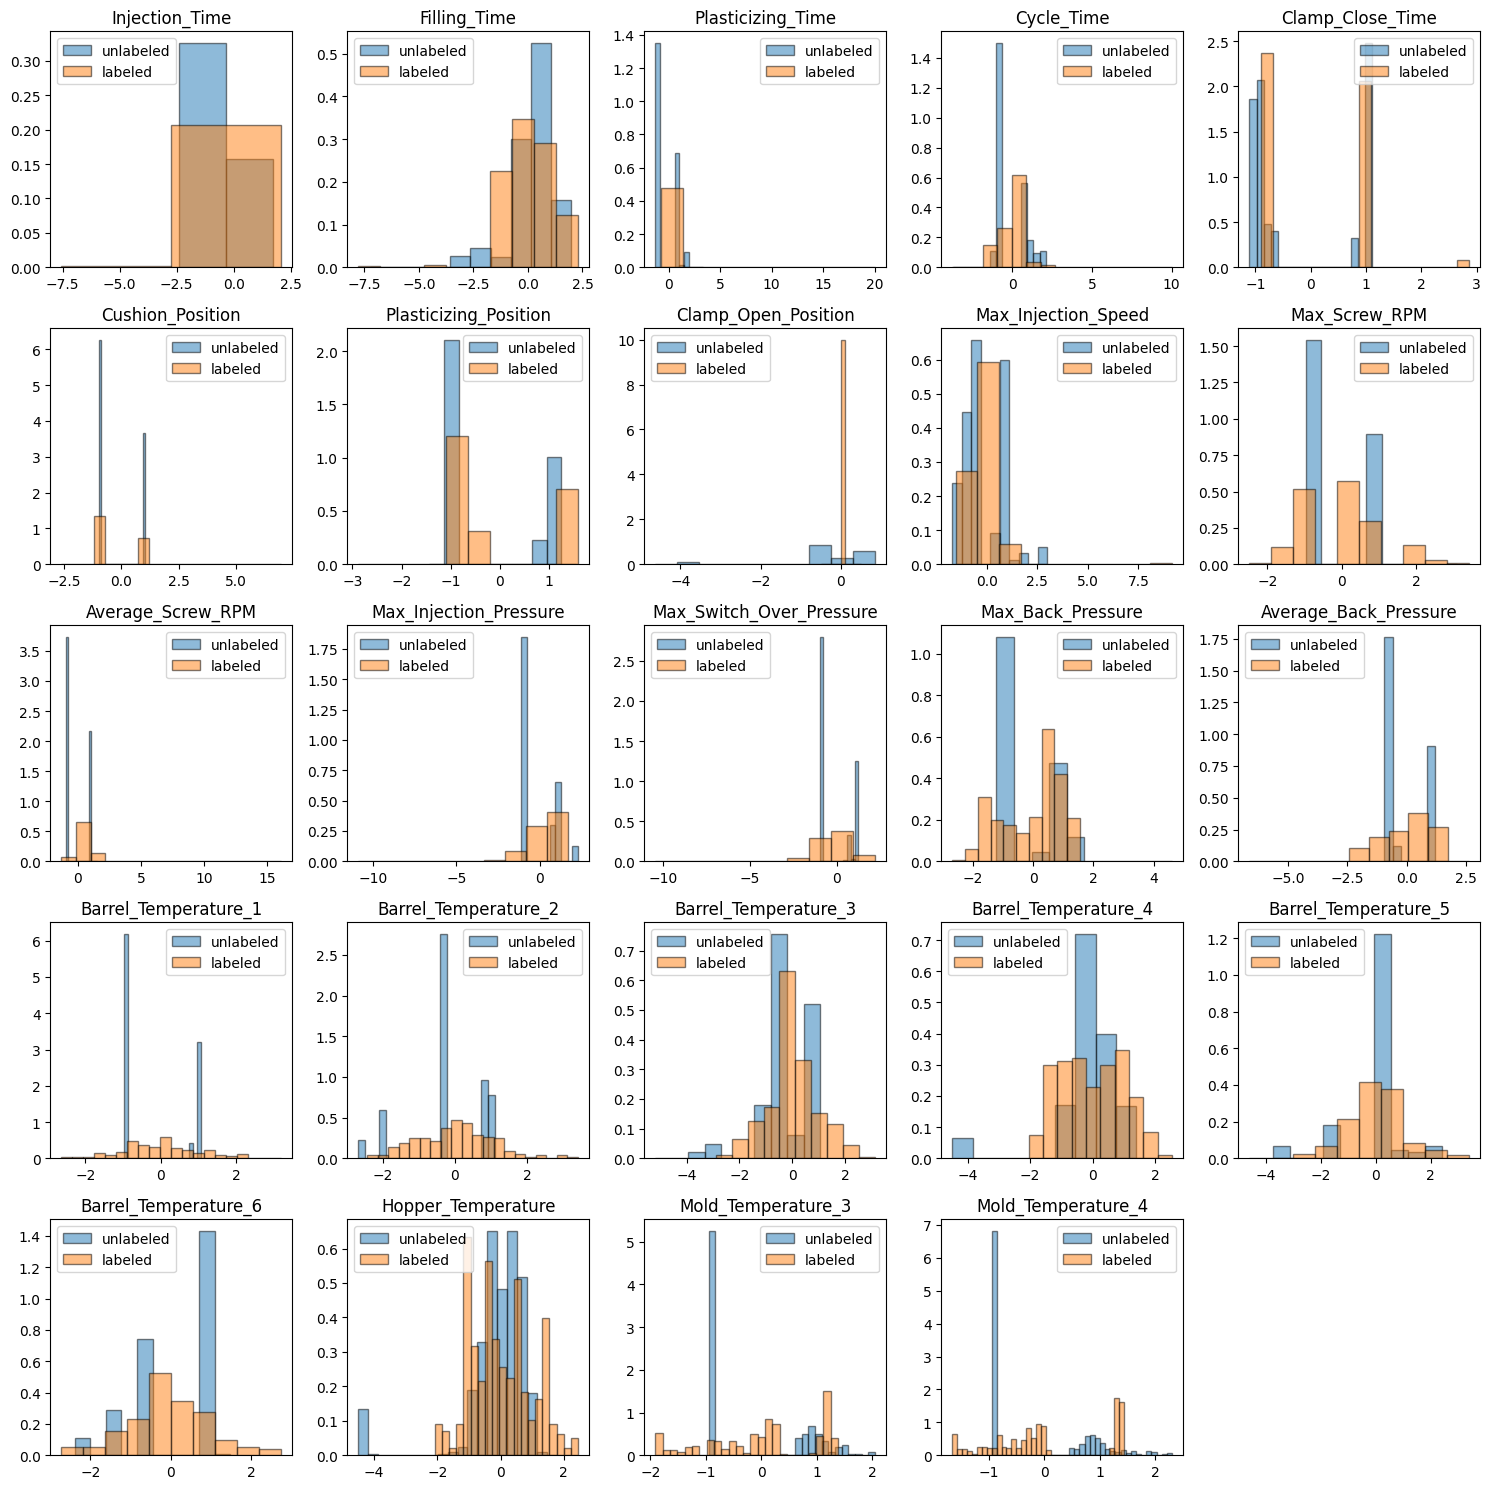

In [65]:
# visualize the distribution of every feature for each products
plt.figure(figsize=(15, 15))

bin = [2,10,10,15,17,20,10,10,10,10,15,10,10,10,10,20,20,10,10,10,10,20,25,35,35]

for index, value in enumerate(unlabeled_cn7.columns):
    ax = plt.subplot(5, 5, index + 1)
    ax.hist(x=unlabeled_cn7[value], bins=bin[index], alpha=0.5, edgecolor='black', label='unlabeled', density=True)
    ax.hist(x=X_with_label_cn7[value], bins=bin[index], alpha=0.5, edgecolor='black', label='labeled', density=True)
    plt.title(value)
    plt.legend()

plt.tight_layout()

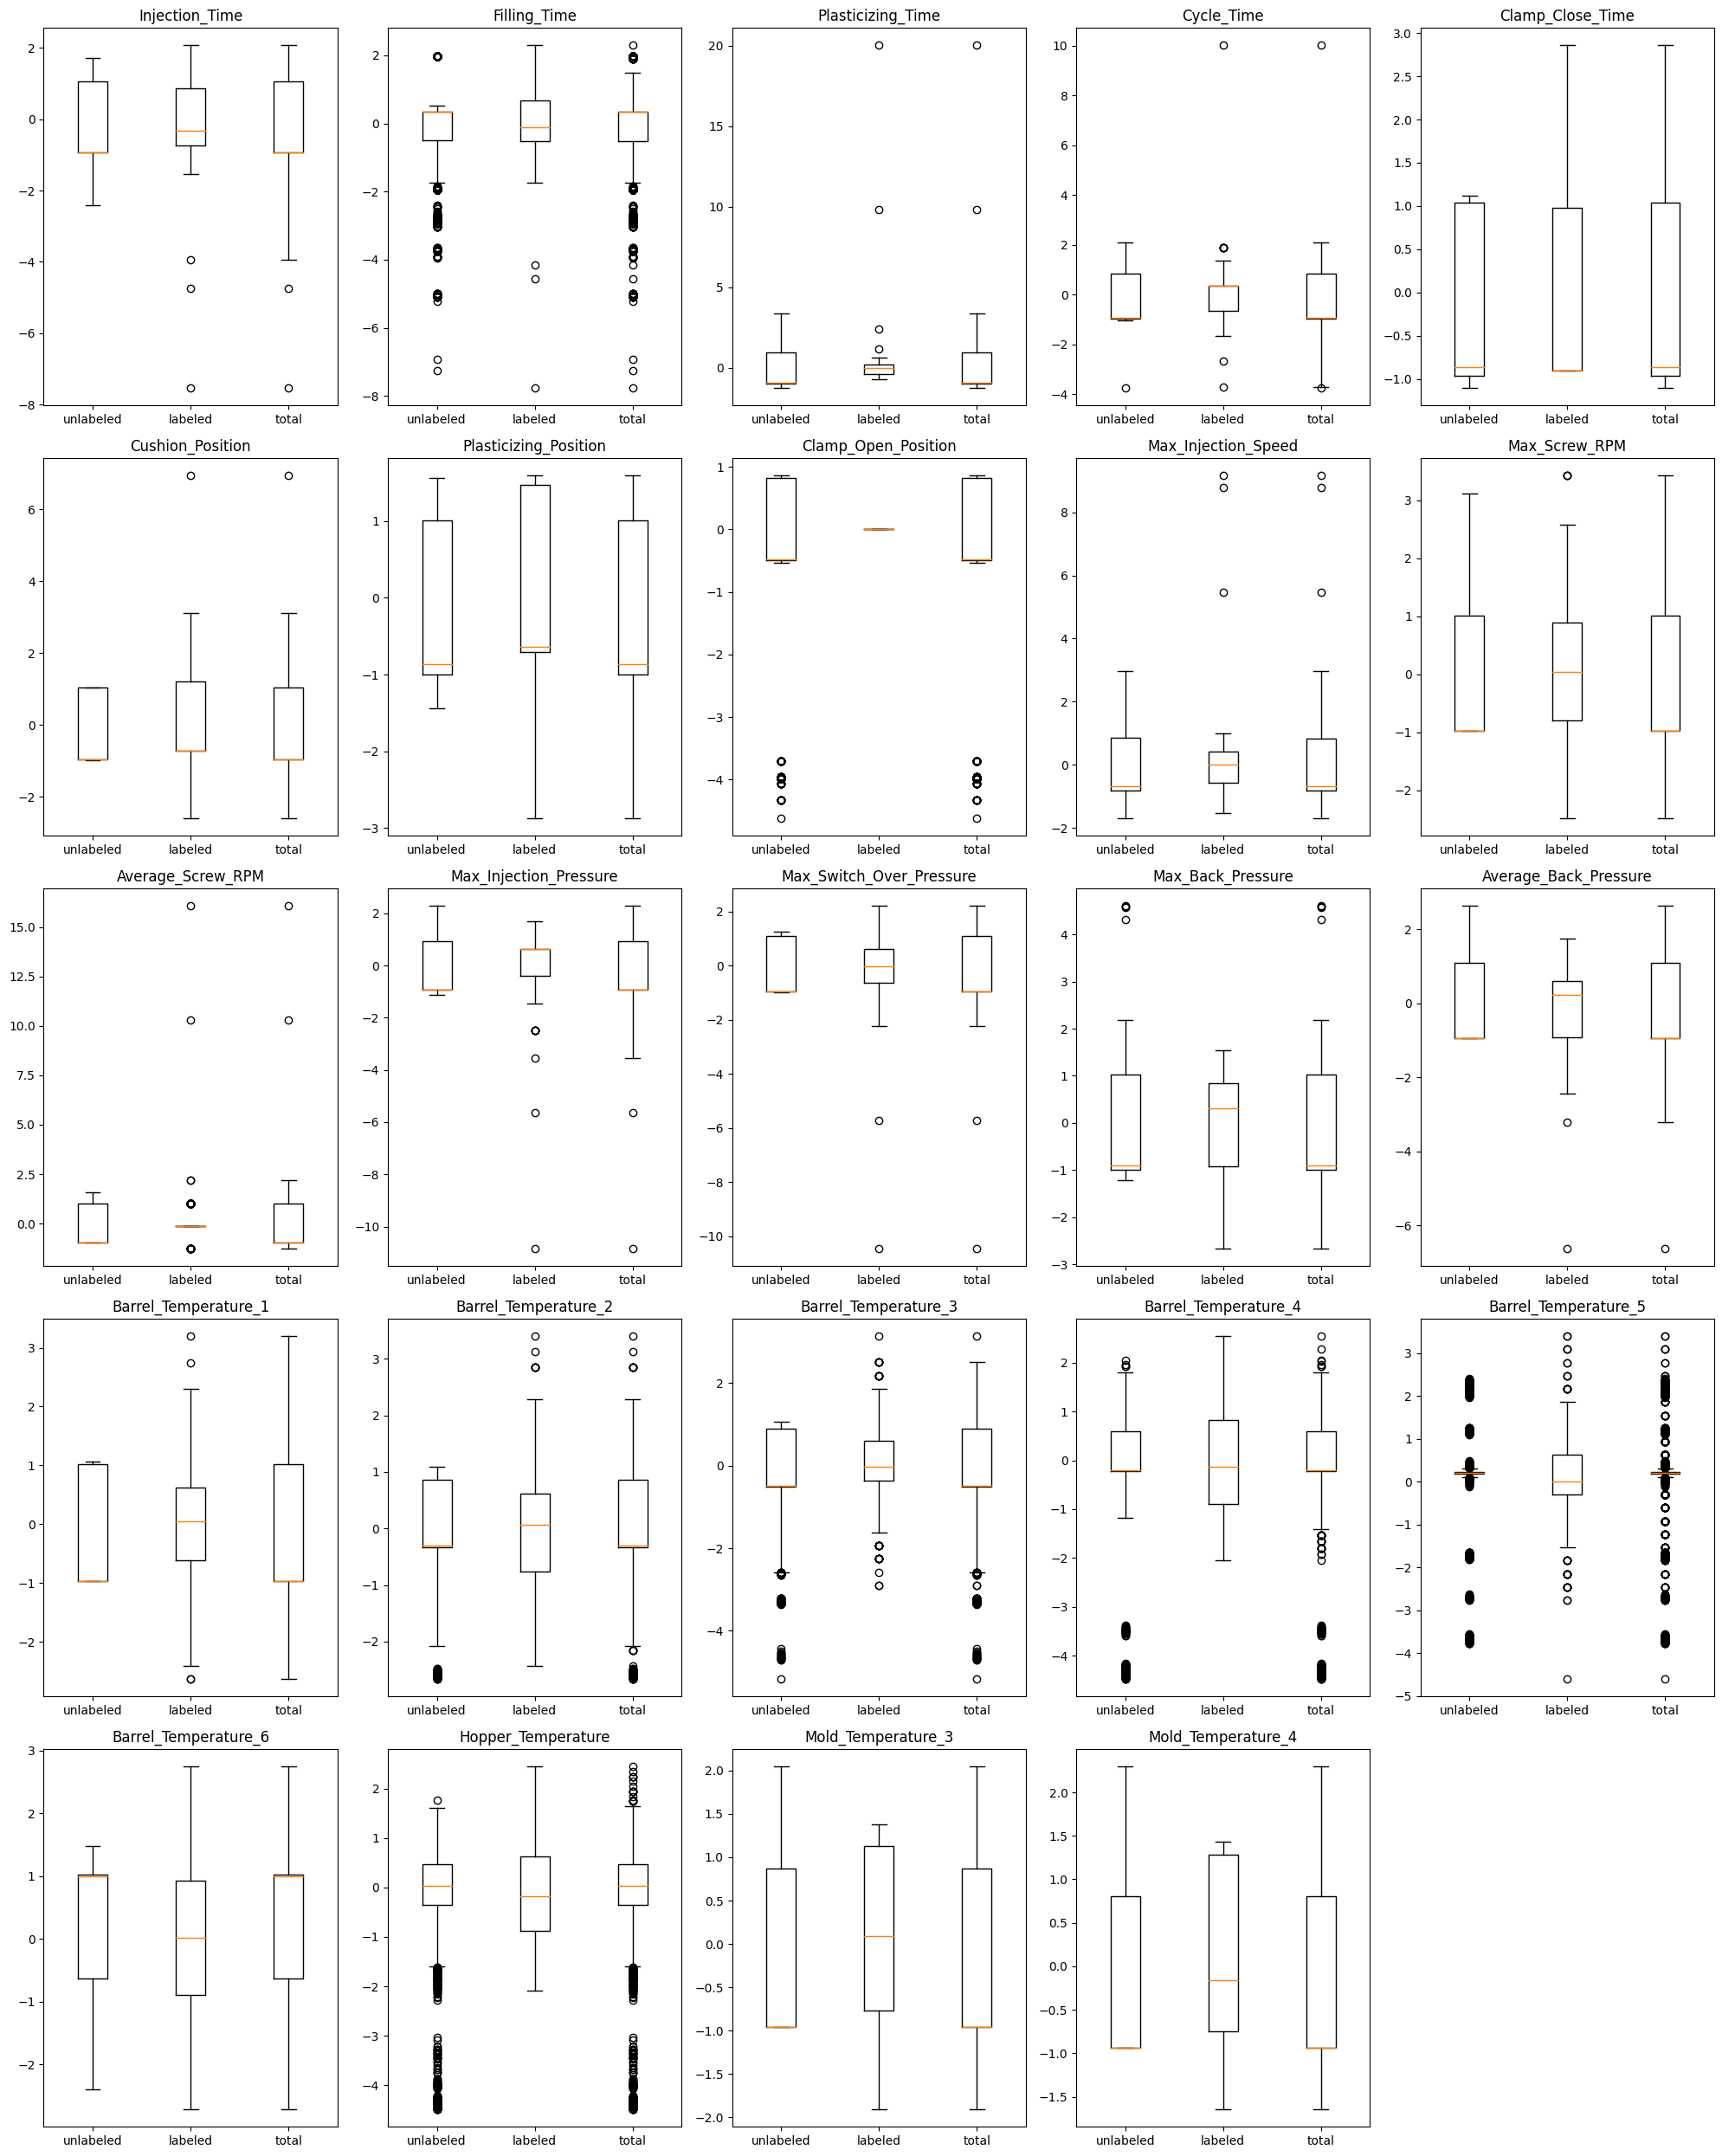

In [67]:
# draw boxplot
total_cn7 = pd.concat([unlabeled_cn7, X_with_label_cn7])
plt.figure(figsize=(20, 25))

for index, value in enumerate(unlabeled_cn7.columns):
    ax = plt.subplot(5, 5, index + 1)
    ax.boxplot(x=[unlabeled_cn7[value],X_with_label_cn7[value],total_cn7[value]], labels=['unlabeled','labeled','total'])
    ax.set_title(value)

plt.tight_layout()

[CN7]
- `labeled` : Clamp_Open_Position이 모두 0
- `unlabeled`: Barrel_Temperature_4, Hopper_Temperature -4 부근의 값 이상치로 보임

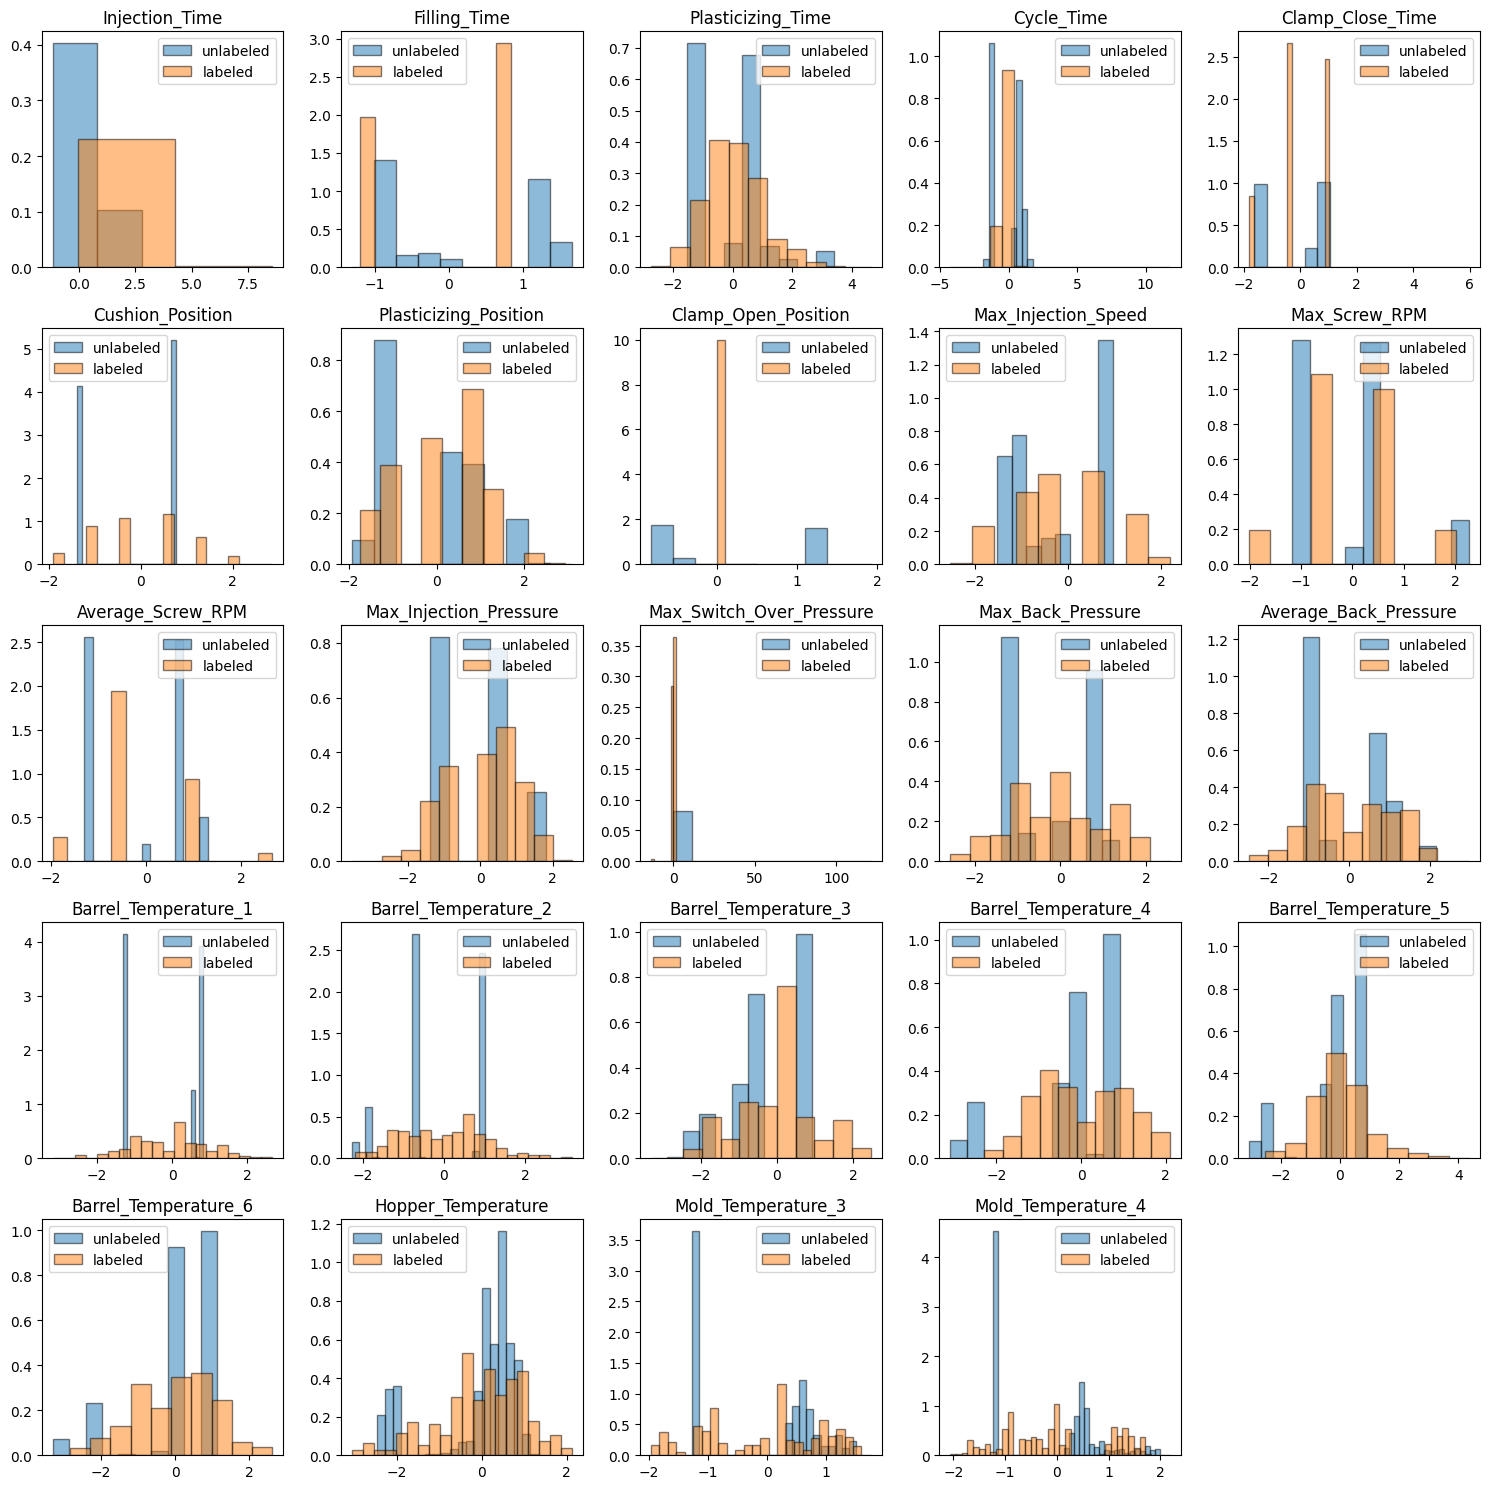

In [68]:
# visualize the distribution of every feature for each products
# Product : RG3
plt.figure(figsize=(15, 15))

bin = [2,10,10,15,17,20,10,10,10,10,15,10,10,10,10,20,20,10,10,10,10,20,25,35,35]

for index, value in enumerate(unlabeled_rg3.columns):
    ax = plt.subplot(5, 5, index + 1)
    ax.hist(x=unlabeled_rg3[value], bins=bin[index], alpha=0.5, edgecolor='black', label='unlabeled', density=True)
    ax.hist(x=X_with_label_rg3[value], bins=bin[index], alpha=0.5, edgecolor='black', label='labeled', density=True)
    plt.title(value)
    plt.legend()

plt.tight_layout()

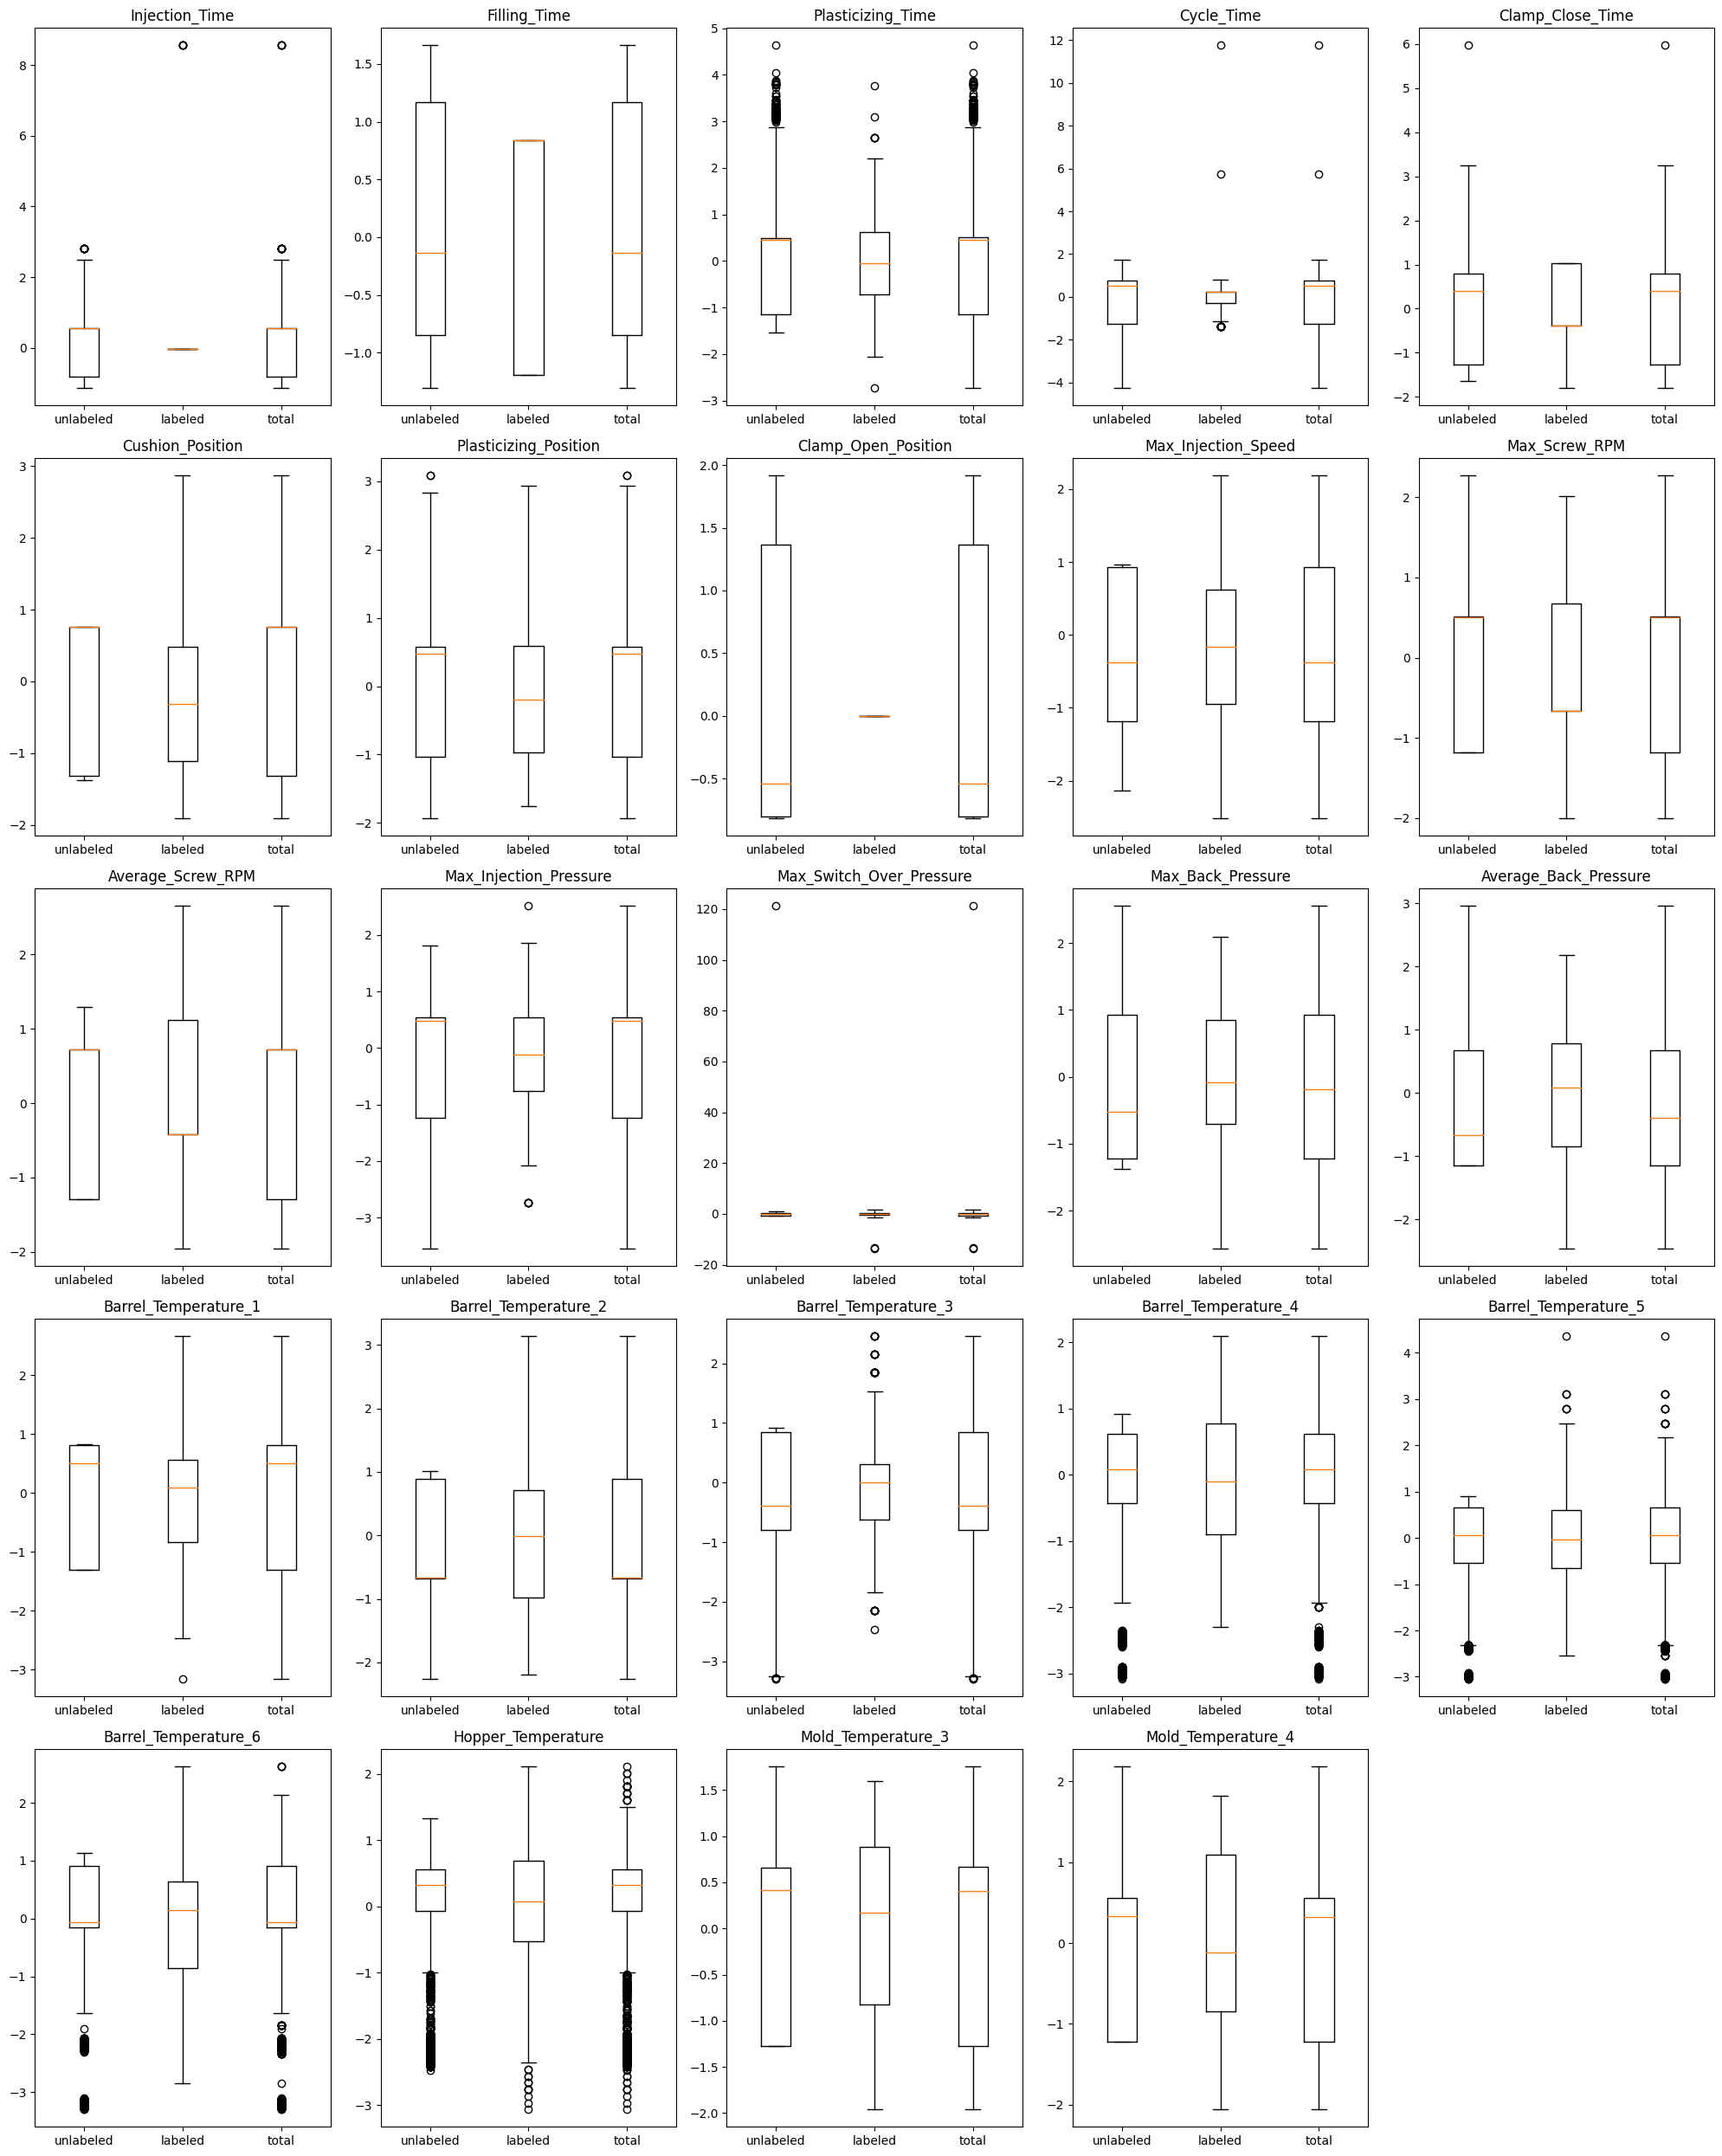

In [69]:
# draw boxplot
total_rg3 = pd.concat([unlabeled_rg3,X_with_label_rg3])
plt.figure(figsize=(20, 25))

for index, value in enumerate(unlabeled_rg3.columns):
    ax = plt.subplot(5, 5, index + 1)
    ax.boxplot(x=[unlabeled_rg3[value],X_with_label_rg3[value],total_rg3[value]], labels=['unlabeled','labeled','total'])
    ax.set_title(value)

plt.tight_layout()

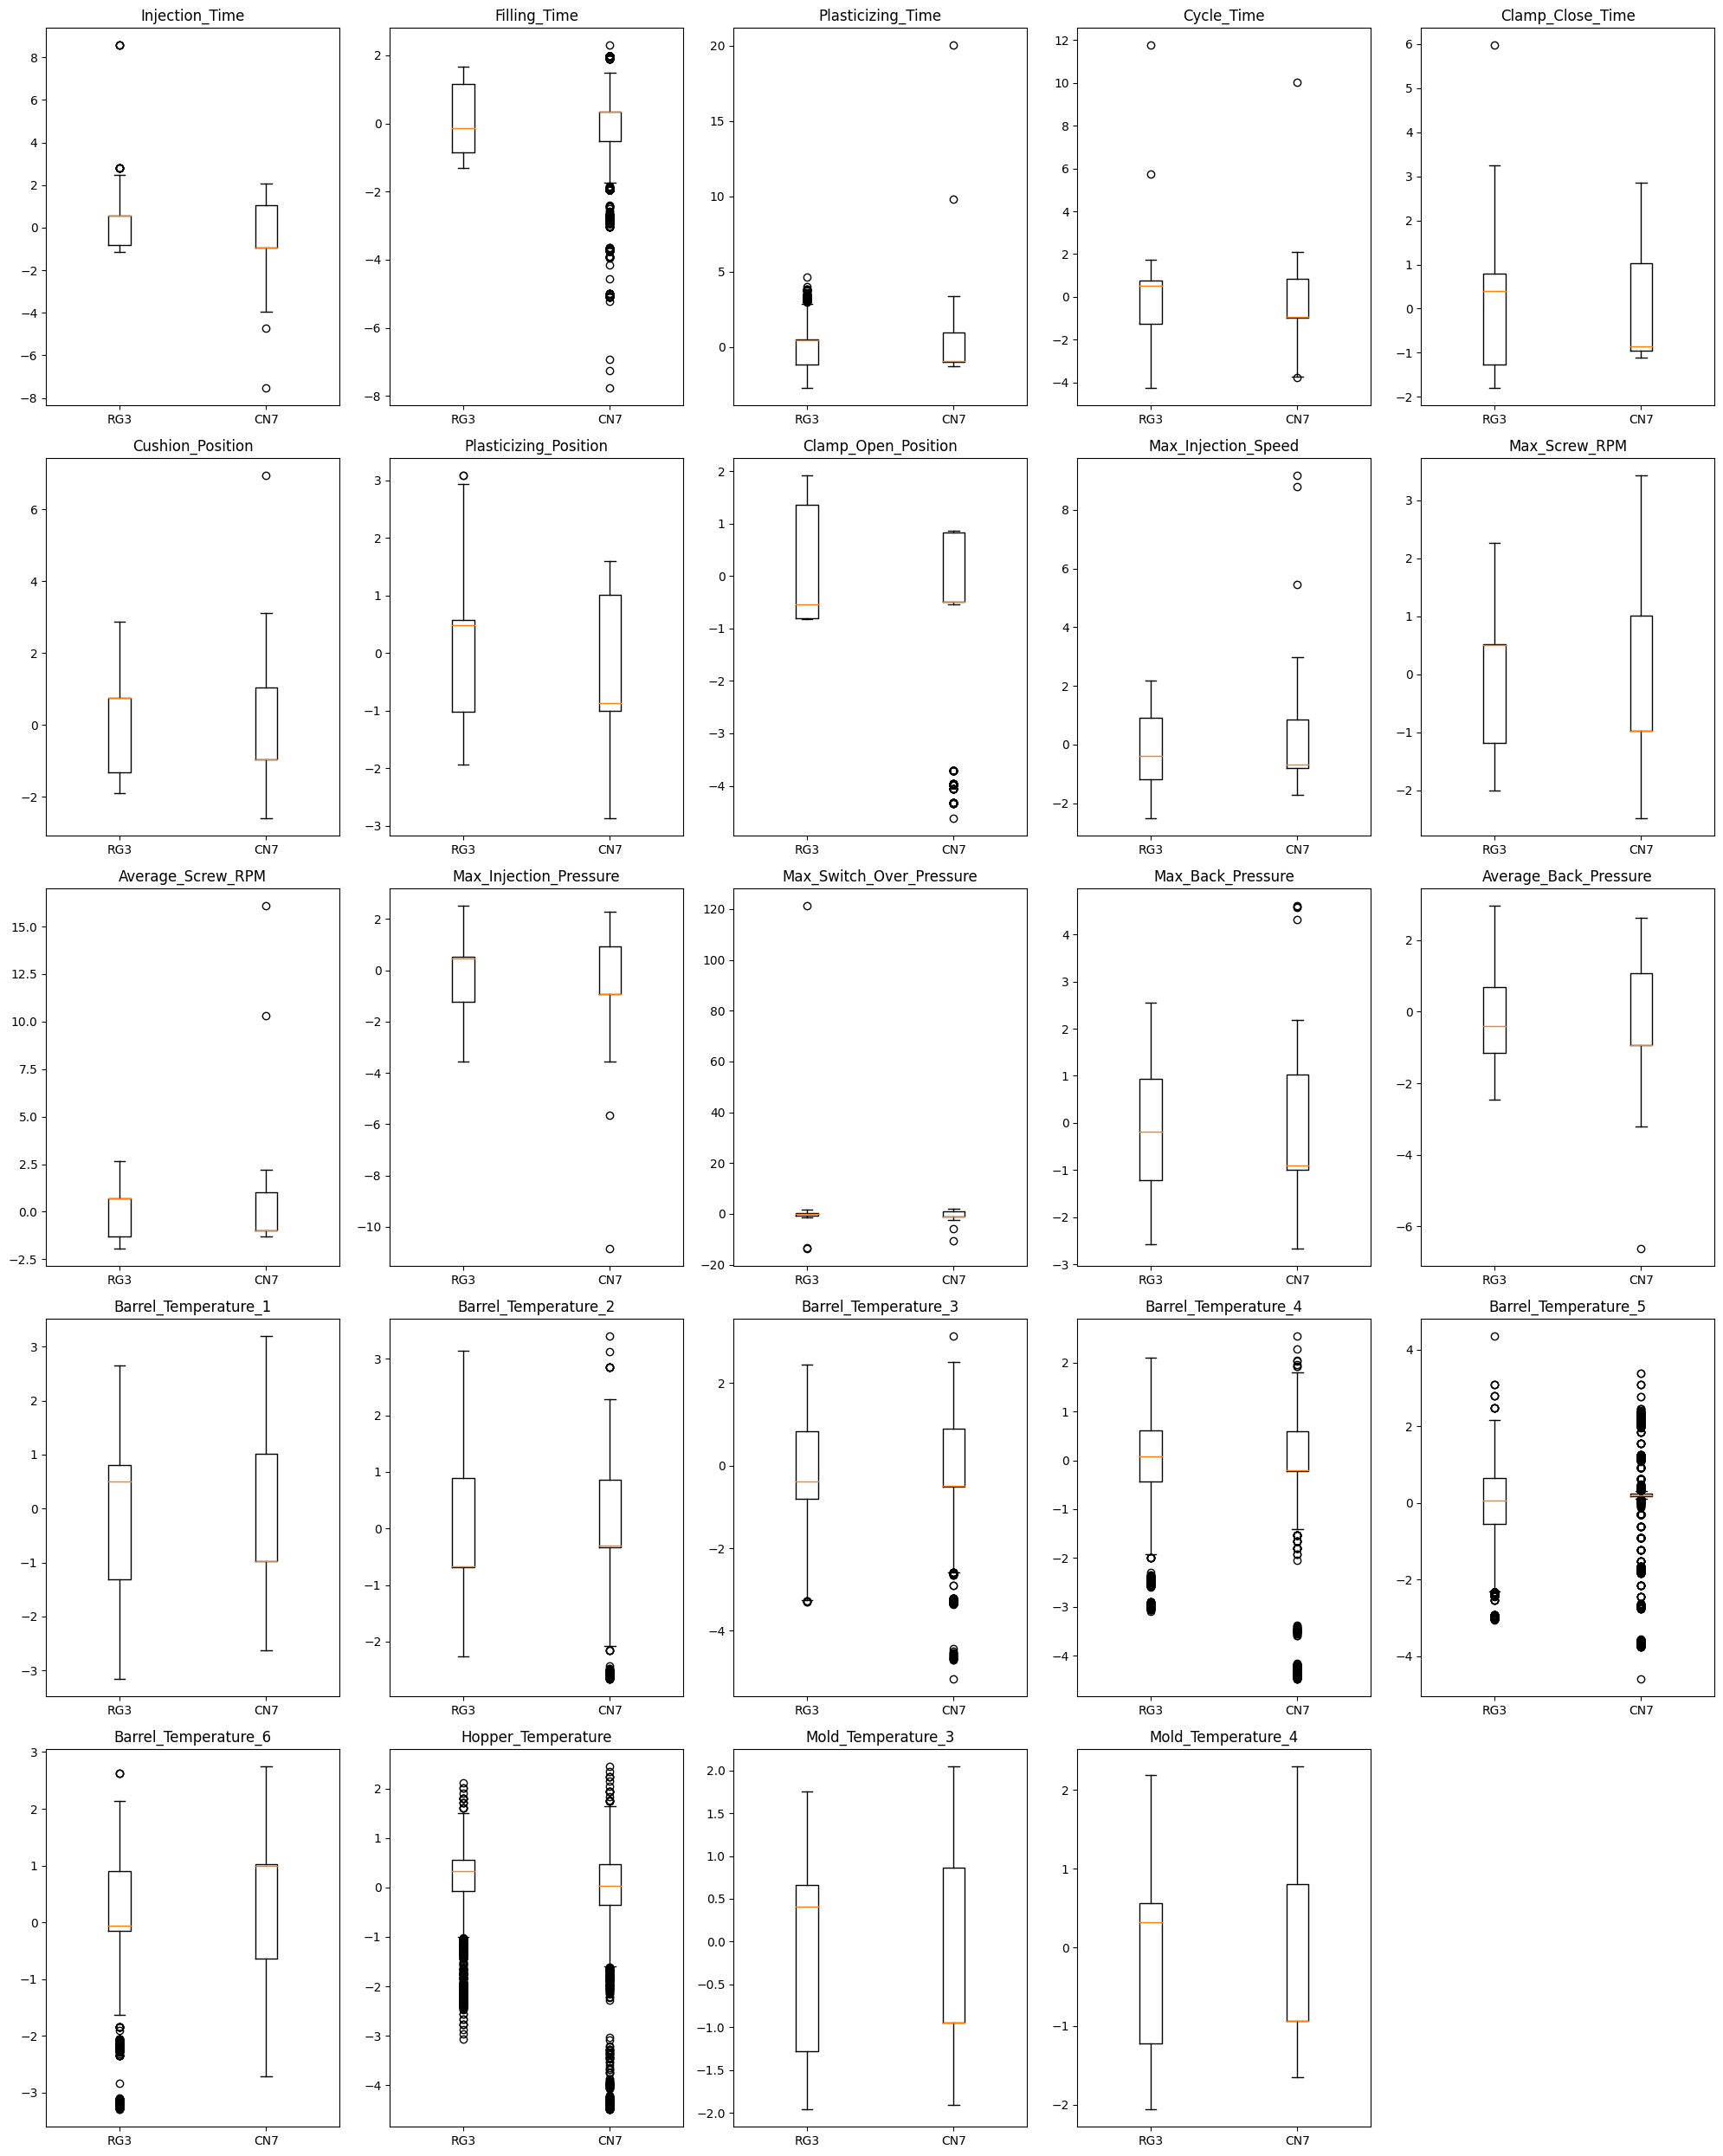

In [71]:
# visualize the distribution of every feature for each products
# used data : total_cn7, total_rg3 (unlabeled+labeled)
plt.figure(figsize=(20, 25))

for index, value in enumerate(total_rg3.columns):
    if value == 'PassOrFail':
        continue
    ax = plt.subplot(5, 5, index + 1)
    ax.boxplot(x=[total_rg3[value],total_cn7[value]], labels=['RG3','CN7'])
    ax.set_title(value)

plt.tight_layout()

CN7, RG3에 따라 피처별 데이터 분포가 다르므로 제품별 전처리를 다르게 할 것

In [72]:
tr_from_labeled_cn7 = pd.concat([X_with_label_cn7, y_with_label_cn7], axis=1)
tr_from_labeled_rg3 = pd.concat([X_with_label_rg3, y_with_label_rg3], axis=1)

display(tr_from_labeled_cn7)
display(tr_from_labeled_rg3)

,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,...,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4,PassOrFail
915,-0.327014,-0.120461,0.258219,0.869452,-0.902466,-0.711164,-0.763064,0.0,0.015756,1.740153,...,0.953402,-1.598068,-0.355039,1.779489,-0.607339,2.290016,1.442471,-0.049915,-0.255156,0
829,-0.327014,-0.120461,0.258219,-0.655762,-0.902466,1.202502,-0.702654,0.0,0.210445,0.049553,...,-0.168176,0.622557,-1.941496,-1.154004,-0.299626,-0.897571,0.536018,-0.192982,-0.354687,0
1015,-0.728249,-0.926390,0.307302,-0.655762,-0.902466,-0.711164,-0.702654,0.0,0.599832,0.049553,...,-2.411332,-0.210156,-0.037728,0.248986,-0.299626,0.013158,1.241040,0.164688,-0.105859,0
263,0.876653,1.088442,-0.428933,0.361047,-0.902466,-0.711164,1.471608,0.0,-0.763018,0.049553,...,0.504743,1.177755,-0.037728,-0.516285,-0.607339,0.013158,-0.773295,1.166162,1.287574,0
569,-0.728249,-0.926390,-0.134441,0.361047,0.978580,1.202502,-0.642290,0.0,0.599832,0.049553,...,0.280414,0.344957,-1.941496,-0.133669,0.008133,0.013158,-0.471149,-1.194457,-1.001638,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
613,-0.327014,-0.120461,0.209135,0.361047,0.978580,1.202502,-0.702654,0.0,0.210445,-1.641030,...,0.056153,0.900156,-0.355039,-0.643836,-2.453801,0.923887,-0.974733,-0.908321,-0.852341,0
133,1.277888,1.088442,-0.379849,0.361047,0.978580,-0.711164,1.471608,0.0,-0.763018,0.049553,...,-0.168176,-0.487756,0.279582,-1.791723,3.085539,0.468557,-0.974733,1.237697,1.387105,0
813,0.475456,0.685468,0.160051,0.361047,-0.902466,-0.711164,-0.642290,0.0,-0.178934,1.740153,...,-0.168176,0.900156,-2.258806,-0.388733,-0.299626,0.468557,0.435303,-0.192982,-0.354687,0
863,-1.530680,-1.329345,0.209135,-0.655762,-0.902466,1.202502,-0.702654,0.0,0.794530,0.049553,...,1.626321,0.344957,-0.672350,0.121435,0.008133,0.923887,0.536018,-0.121448,-0.304922,0


,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,...,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4,PassOrFail
1233,-0.029099,-1.192531,2.202217,0.249511,1.033078,1.277707,-0.192928,0.0,1.402554,0.677109,...,0.329736,0.230835,0.305246,0.925242,0.596220,-0.851297,0.284910,-1.678451,-1.818827,0
1461,-0.029099,-1.192531,1.304298,0.249511,-0.386790,1.277707,1.369662,0.0,1.402554,0.677109,...,-2.001197,-0.011452,-0.002081,-0.975955,-0.657751,-2.342787,-0.020131,-1.108521,-0.847689,0
1351,-0.029099,-1.192531,2.651155,0.249511,-0.386790,-0.317055,-0.192928,0.0,0.617645,-0.665752,...,0.562844,2.412012,0.305246,-1.707191,1.223110,-0.354184,1.505060,-1.108521,-1.090474,0
1217,-0.029099,-1.192531,2.202217,0.249511,1.033078,1.277707,-1.755816,0.0,1.402554,-0.665752,...,-1.535053,0.715557,-1.538626,0.925242,-0.657751,-0.851297,0.284910,-1.393485,-1.576042,0
2097,-0.029099,0.838552,-0.940436,-0.846822,-1.806725,-1.911818,0.588367,0.0,-1.737322,-0.665752,...,-2.234305,0.230835,-0.002081,0.925242,-1.284641,-1.845598,-0.325165,1.171203,1.215973,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1639,-0.029099,0.838552,0.630880,0.249511,1.033078,-0.317055,0.588367,0.0,-0.167384,0.677109,...,-0.835730,0.715557,-0.002081,0.632729,-0.030765,-0.851297,0.691629,0.173825,-0.119337,0
1955,-0.029099,0.838552,-0.267018,0.249511,-0.386790,-1.114437,-0.192928,0.0,-1.737322,-0.665752,...,0.329736,-1.223184,0.612574,0.486518,1.223110,0.640193,-1.850360,-1.251002,-0.847689,0
1447,-0.029099,-1.192531,0.630880,0.249511,-0.386790,0.480326,-0.192928,0.0,0.617645,0.677109,...,-1.068838,-0.738536,-1.845954,-0.244719,-0.344258,0.143005,0.691629,-0.823555,-0.847689,0
2085,-0.029099,0.838552,-0.940436,0.249511,-1.806725,-0.317055,-0.192928,0.0,-0.952293,0.677109,...,0.795880,-0.738536,0.305246,0.194005,-0.657751,0.640193,-0.833562,1.171203,1.215973,0


In [73]:
# correlation between features and target variable
corr_cn7 = pd.DataFrame(tr_from_labeled_cn7.corr()['PassOrFail']).reset_index(names='features')
corr_rg3 = pd.DataFrame(tr_from_labeled_rg3.corr()['PassOrFail']).reset_index(names='features')
corr_coef = pd.merge(left=corr_cn7, right=corr_rg3, how='left', on='features')
corr_coef.rename(columns={'PassOrFail_x':'corr_cn7','PassOrFail_y':'corr_rg3'}, inplace=True)
corr_coef.sort_values(by='corr_cn7', ascending=False)

,features,corr_cn7,corr_rg3
24,PassOrFail,1.000000,1.000000
6,Plasticizing_Position,0.297018,-0.005850
23,Mold_Temperature_4,0.273556,-0.047721
4,Clamp_Close_Time,0.258030,0.034388
22,Mold_Temperature_3,0.245349,-0.054911
1,Filling_Time,0.183015,-0.006193
0,Injection_Time,0.180014,-0.028324
3,Cycle_Time,0.151783,0.032613
12,Max_Switch_Over_Pressure,0.094215,0.037576
20,Barrel_Temperature_6,0.079075,0.007364


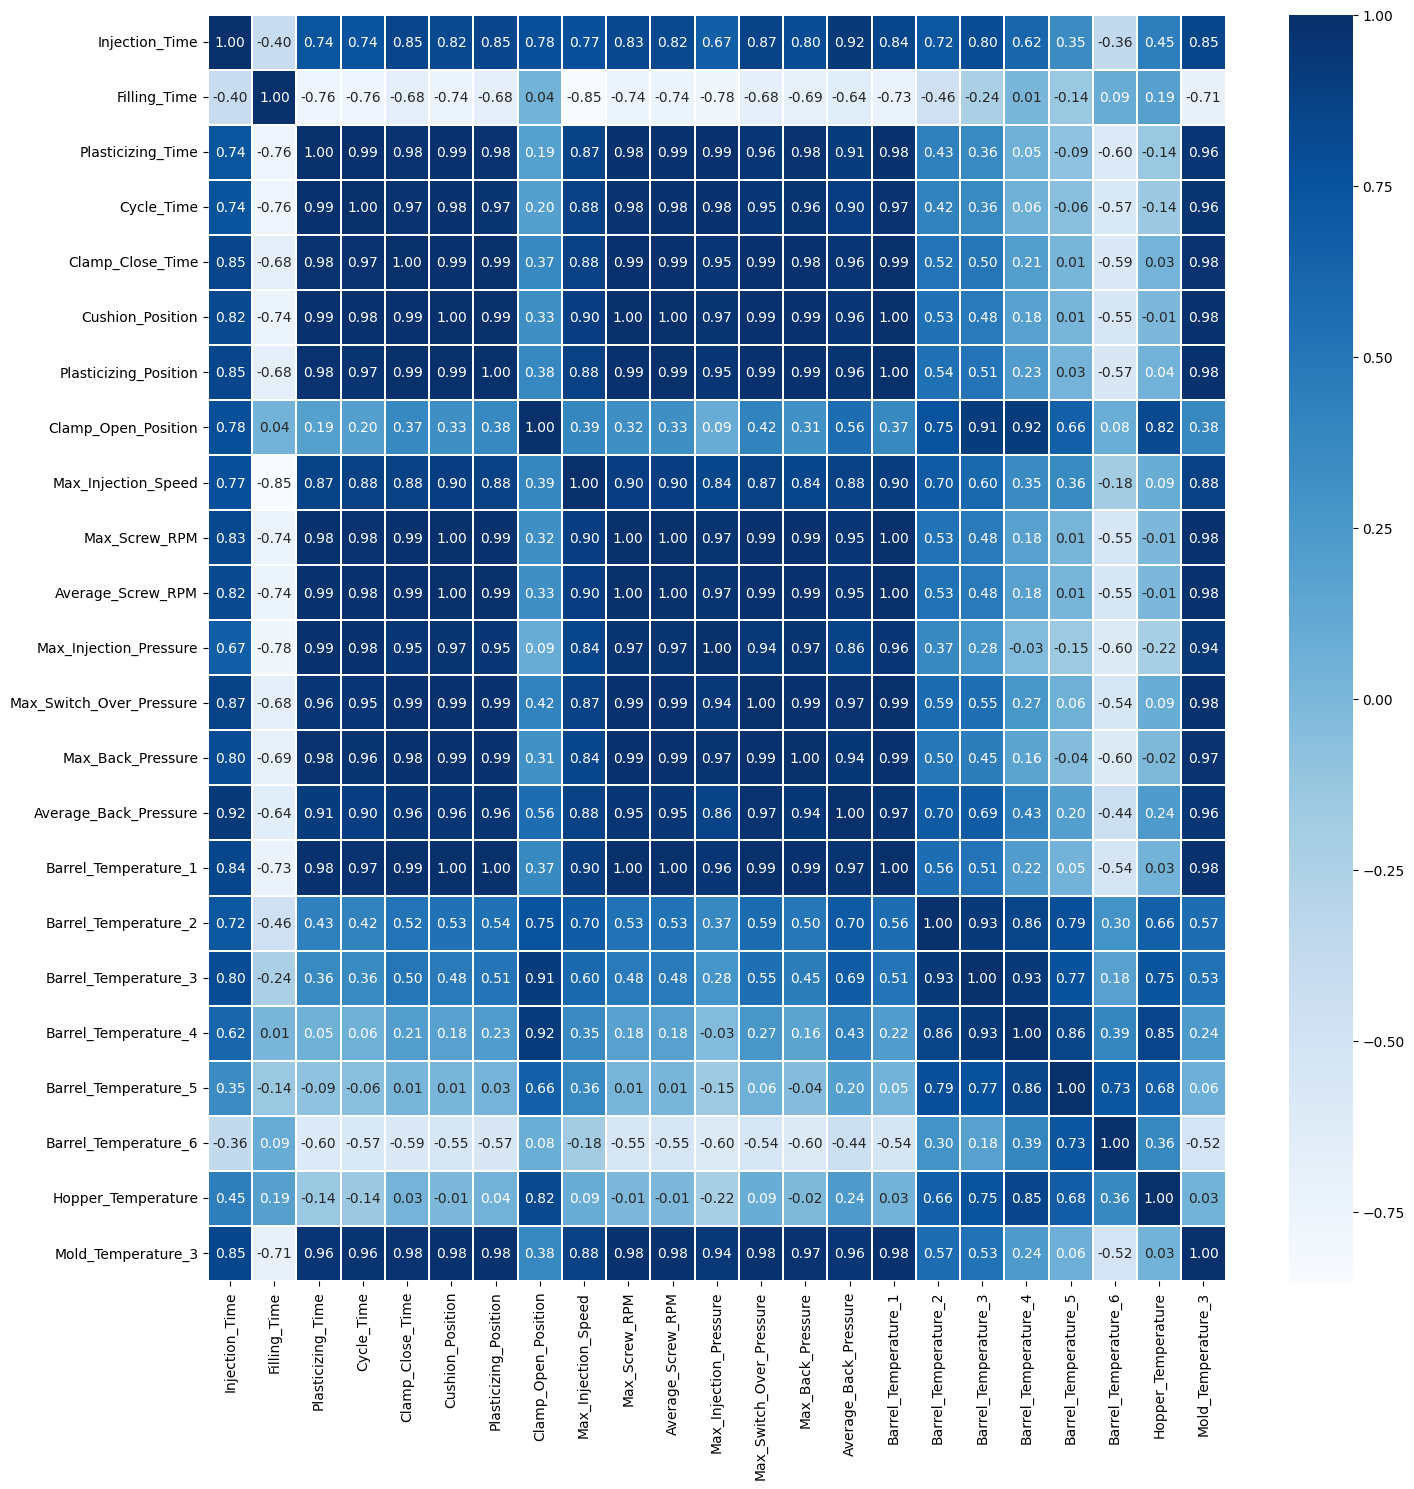

In [74]:
# correlation heatmap
# unlabeled_cn7, without target variable
plt.subplots(figsize=(15,15))
sns.heatmap(data=unlabeled_cn7.iloc[:,:-1].corr(), annot=True, fmt='.2f', linewidths=0.1, cmap='Blues')
plt.tight_layout()

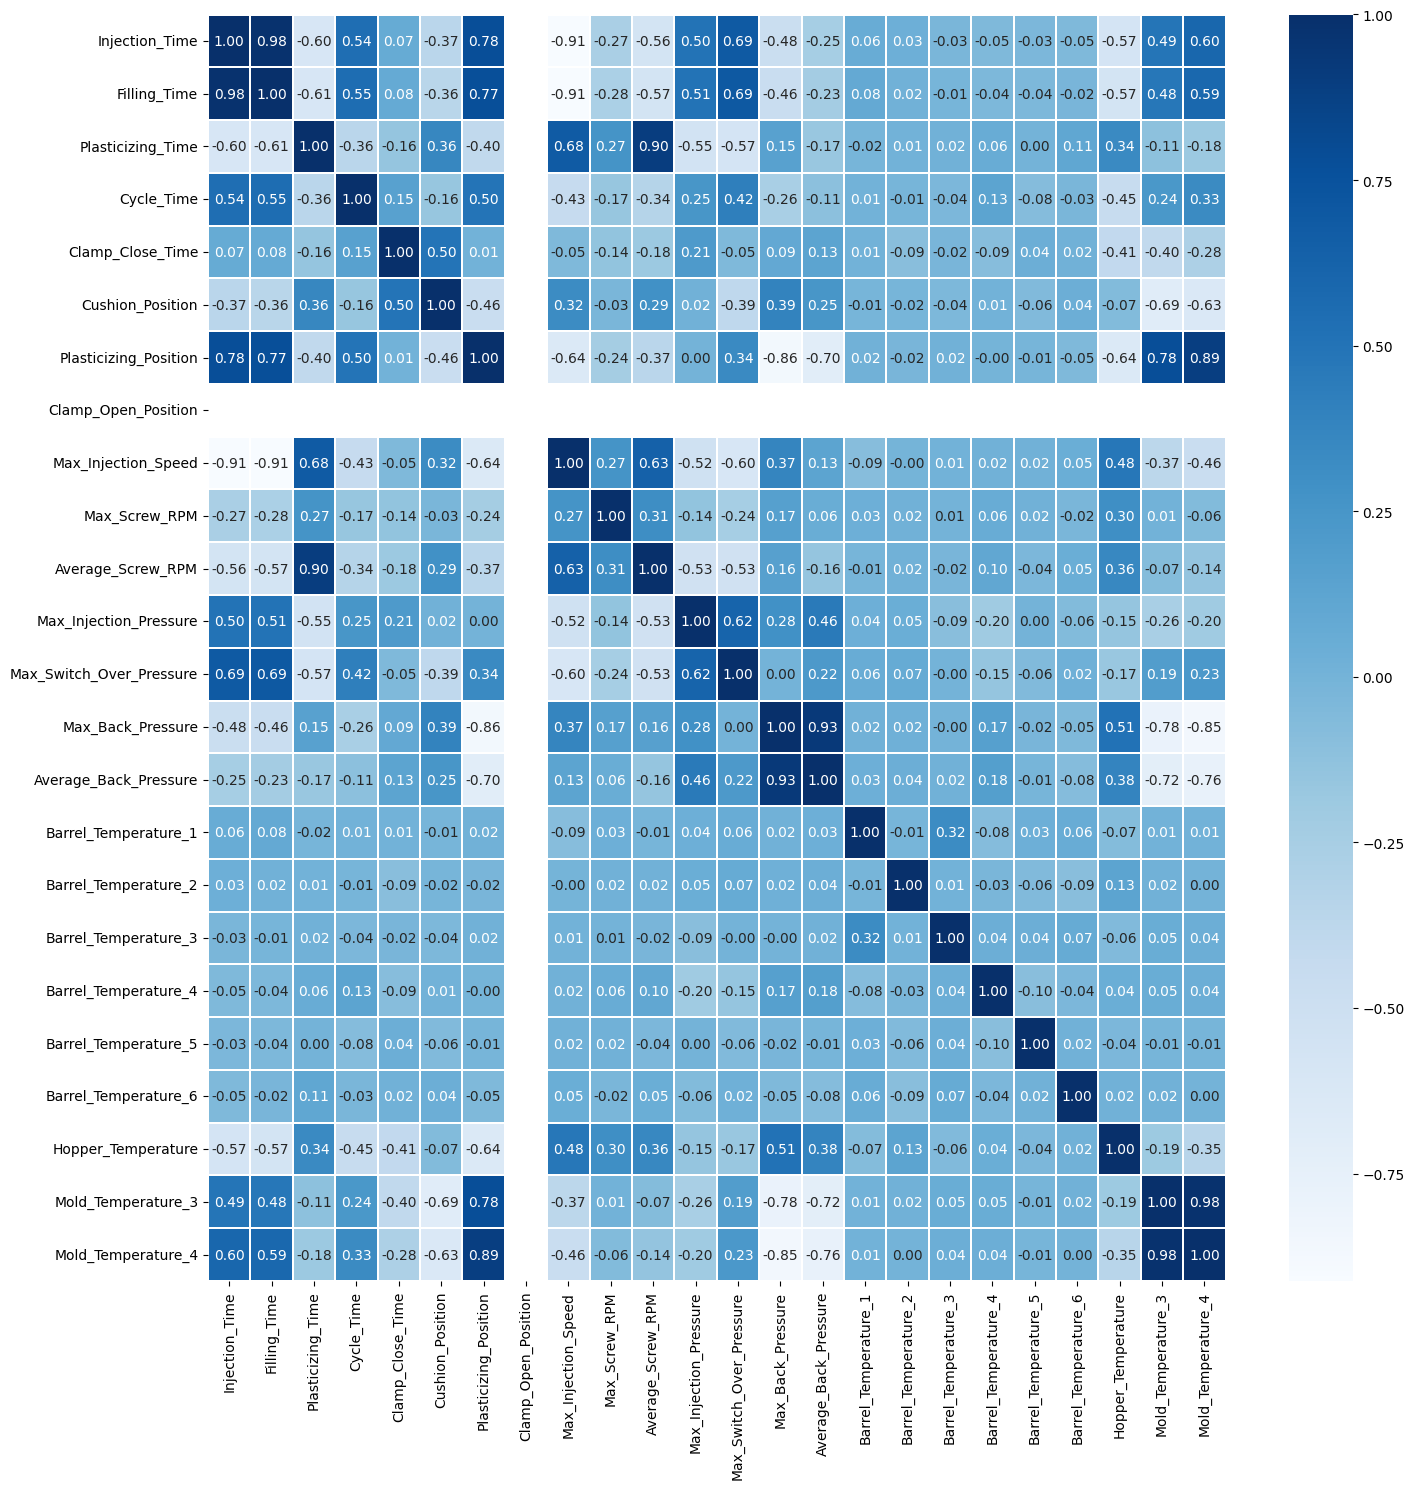

In [75]:
# correlation heatmap
# tr_from_labeled_cn7, without target variable
plt.subplots(figsize=(15,15))
sns.heatmap(data=tr_from_labeled_cn7.iloc[:,:-1].corr(), annot=True, fmt='.2f', linewidths=0.1, cmap='Blues')
plt.tight_layout()

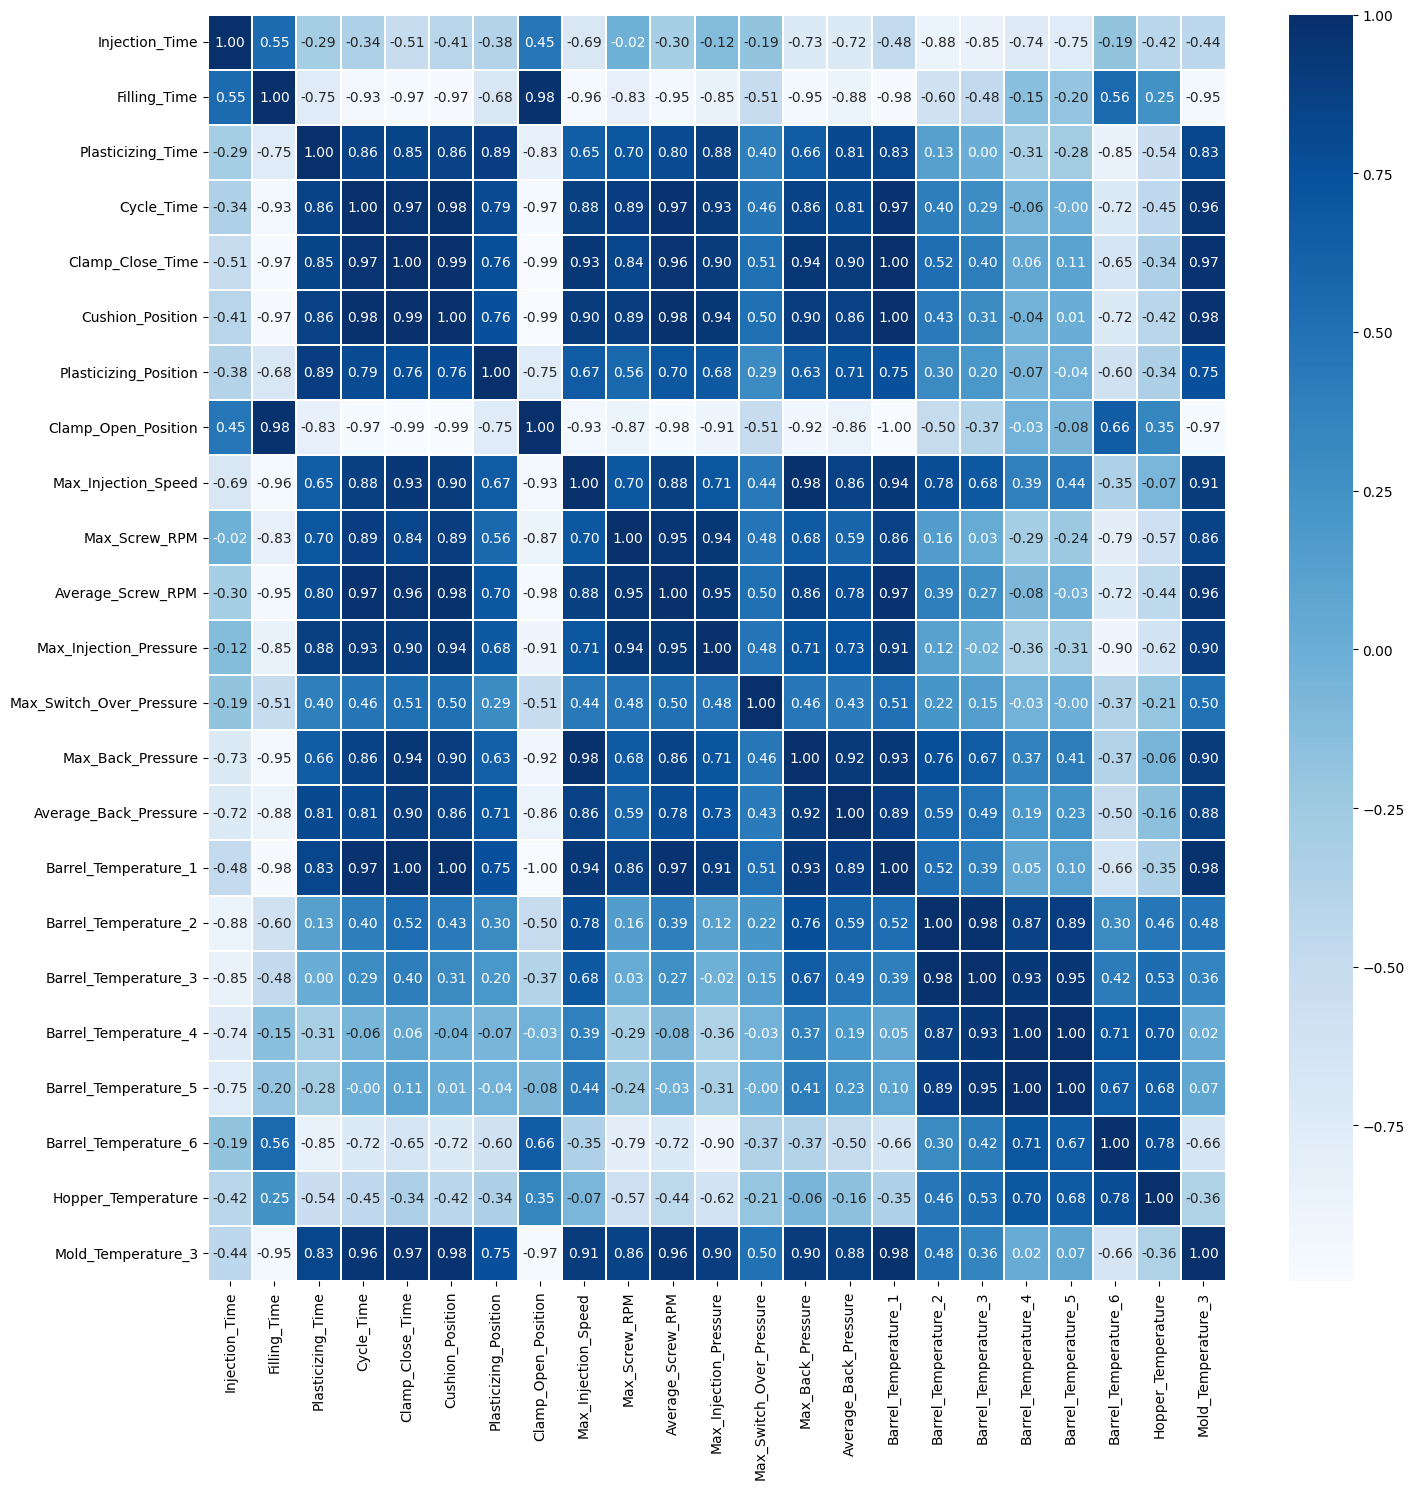

In [76]:
# correlation heatmap
# unlabeled_rg3, without target variable
plt.subplots(figsize=(15,15))
sns.heatmap(data=unlabeled_rg3.iloc[:,:-1].corr(), annot=True, fmt='.2f', linewidths=0.1, cmap='Blues')
plt.tight_layout()

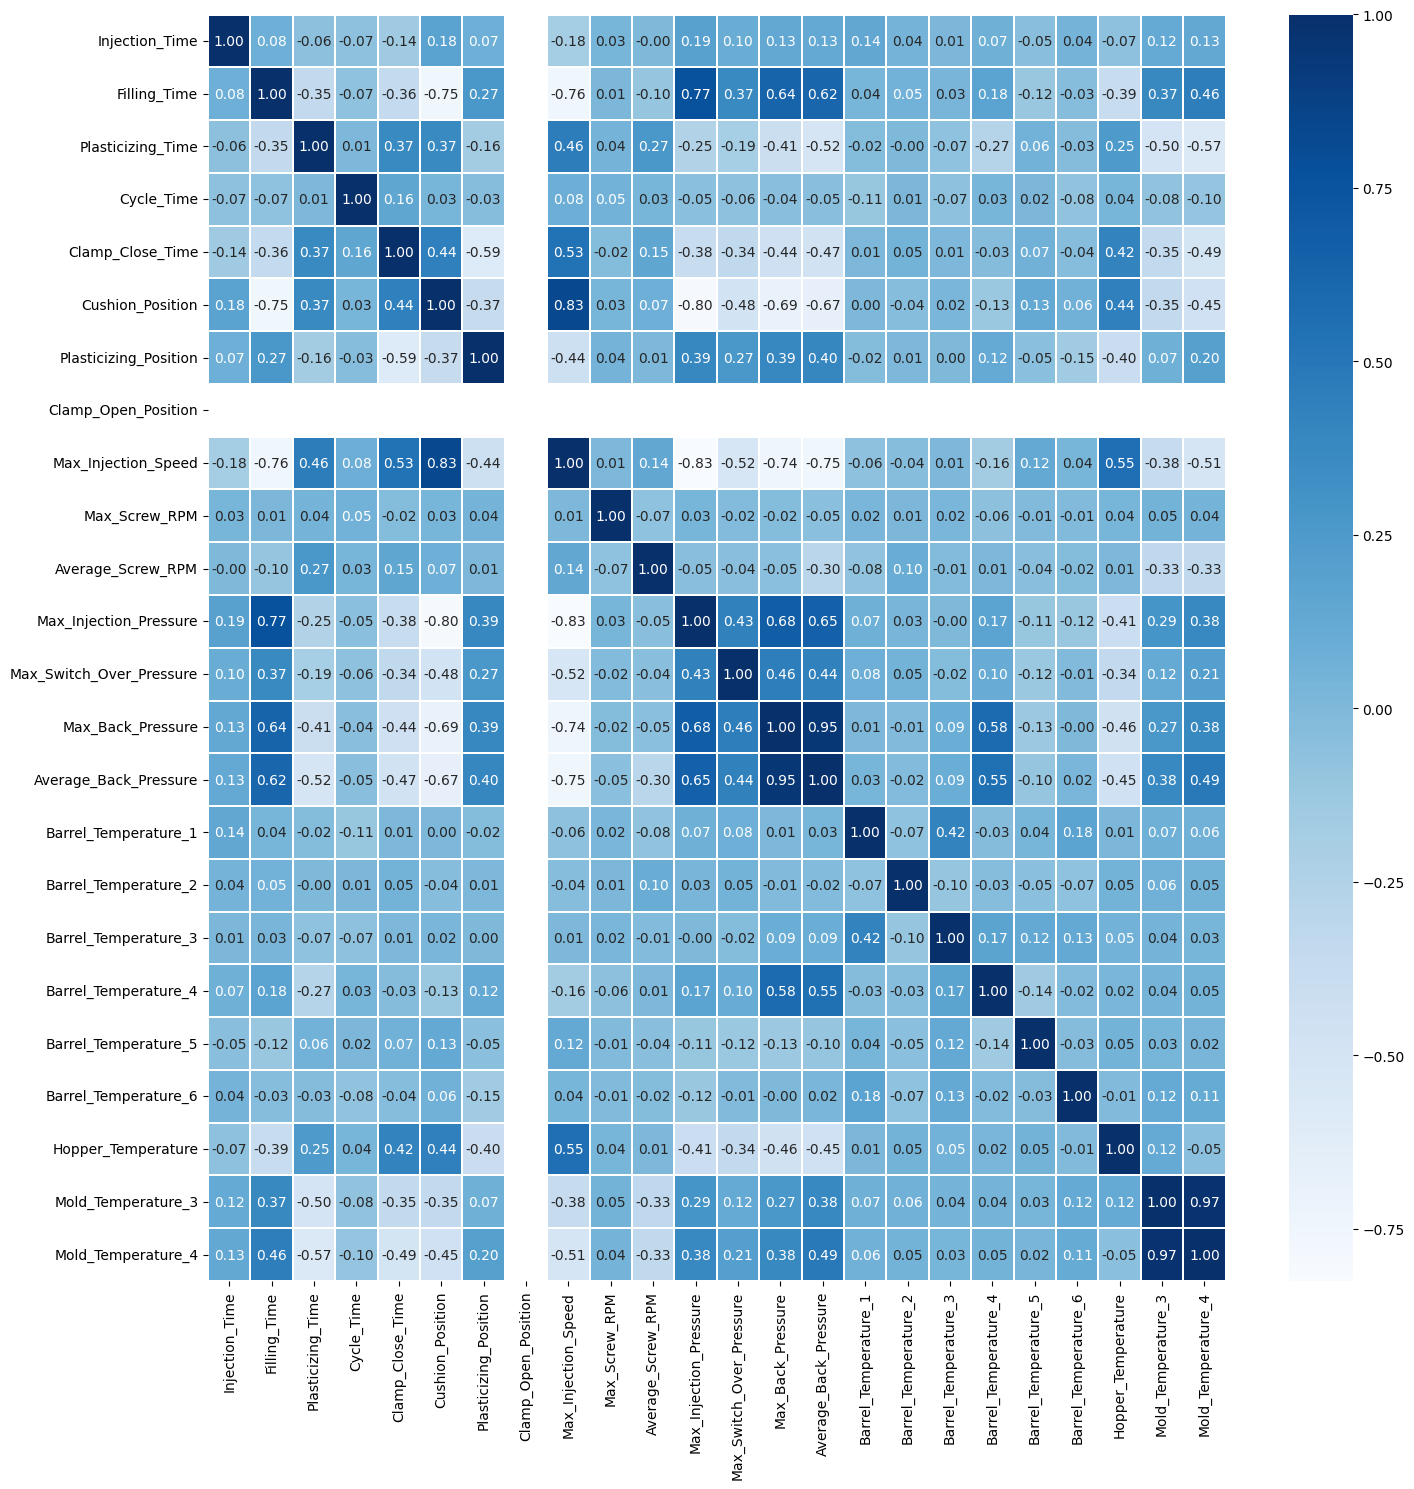

In [77]:
# correlation heatmap
# tr_from_labeled_rg3, without target variable
plt.subplots(figsize=(15,15))
sns.heatmap(data=tr_from_labeled_rg3.iloc[:,:-1].corr(), annot=True, fmt='.2f', linewidths=0.1, cmap='Blues')
plt.tight_layout()

### **(⚠️해결, 무시하시오) Problem 1. Duplicated data**

feature 값이 모두 동일함에도 불량여부가 다른 데이터가 확인됨

[확인 결과]
- CN7 
    - feature 값만 동일한 행의 개수 : 299 (2개씩 값이 같음 -> 598개 중복)
    - target 값까지 동일한 행의 개수 : 293 (*2 = 586)
    - train labeled data에서는 6(12)개의 행이 불량여부가 다르게 나옴
    - train set의 불량품 12개 중 6개는 이 "이상치"에서 나옴
    - 해당 "이상치"들은 연이어 발생 (index가 붙어있음)

#### (⚠️무시) CN7

In [21]:
print(X_with_label_cn7.duplicated().sum())      # feature 값만 동일한 행의 개수 (299)
print(tr_from_labeled_cn7.duplicated().sum())   # feature 값과 target 값까지 동일한 행의 개수 (293)

print(X_with_label_cn7.duplicated(keep=False).sum())      # feature 값만 동일한 행의 개수 (299)
print(tr_from_labeled_cn7.duplicated(keep=False).sum())   # feature 값과 target 값까지 동일한 행의 개수 (293)


299
293
598
586


In [87]:
duplicated_features = set(np.where(X_with_label_cn7.duplicated(keep=False)==True)[0])
duplicated_all = set(np.where(tr_from_labeled_cn7.duplicated(keep=False)==True)[0])
duplicated_outliers = duplicated_features - duplicated_all  # feature 값은 동일하지만 target 값이 다른 행의 index (outliers)

tr_from_labeled_cn7.iloc[list(duplicated_outliers)].sort_index()

,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,...,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4,PassOrFail,duplicated_outliers
47,1.277888,1.491397,-0.625267,0.361047,0.978580,-0.711164,1.471608,0.0,-1.152398,-1.641030,...,-0.210156,0.279582,1.269321,0.623605,0.923887,-0.269711,1.166162,1.287574,1,1
48,1.277888,1.491397,-0.625267,0.361047,0.978580,-0.711164,1.471608,0.0,-1.152398,-1.641030,...,-0.210156,0.279582,1.269321,0.623605,0.923887,-0.269711,1.166162,1.287574,0,1
79,2.080358,1.894372,-0.478017,0.361047,0.978580,-0.711164,1.471608,0.0,-1.347095,0.049553,...,0.900156,-0.037728,-0.388733,1.546836,0.923887,-1.276879,1.309231,1.387105,0,1
80,2.080358,1.894372,-0.478017,0.361047,0.978580,-0.711164,1.471608,0.0,-1.347095,0.049553,...,0.900156,-0.037728,-0.388733,1.546836,0.923887,-1.276879,1.309231,1.387105,1,1
99,1.679123,1.491397,-0.428933,1.377857,0.978580,-0.711164,1.471608,0.0,-0.957708,-1.641030,...,0.344957,-1.941496,0.631602,0.315892,-1.352970,-0.773295,1.237697,1.387105,1,1
100,1.679123,1.491397,-0.428933,1.377857,0.978580,-0.711164,1.471608,0.0,-0.957708,-1.641030,...,0.344957,-1.941496,0.631602,0.315892,-1.352970,-0.773295,1.237697,1.387105,0,1
101,1.277888,1.491397,-0.428933,1.377857,0.978580,-0.711164,1.471608,0.0,-0.957708,0.894853,...,-1.320553,0.279582,1.141770,0.315892,-1.352970,-1.075448,1.309231,1.387105,1,1
102,1.277888,1.491397,-0.428933,1.377857,0.978580,-0.711164,1.471608,0.0,-0.957708,0.894853,...,-1.320553,0.279582,1.141770,0.315892,-1.352970,-1.075448,1.309231,1.387105,0,1
107,0.475456,0.282513,-0.478017,0.361047,0.978580,-0.711164,1.471608,0.0,-0.373631,-0.795730,...,-1.598068,-2.258806,0.121435,-0.915098,0.468557,-0.571865,1.166162,1.337339,1,1
108,0.475456,0.282513,-0.478017,0.361047,0.978580,-0.711164,1.471608,0.0,-0.373631,-0.795730,...,-1.598068,-2.258806,0.121435,-0.915098,0.468557,-0.571865,1.166162,1.337339,0,1


In [88]:
tr_from_labeled_cn7['PassOrFail'].value_counts()

PassOrFail
0    835
1     12
Name: count, dtype: int64

In [89]:
# 단순히 중복된 행
tr_from_labeled_cn7.iloc[list(duplicated_all)]['PassOrFail'].value_counts()

PassOrFail
0    584
1      2
Name: count, dtype: int64

In [90]:
duplicated_outliers_1 = tr_from_labeled_cn7.iloc[list(duplicated_outliers)][tr_from_labeled_cn7.iloc[list(duplicated_outliers)]['PassOrFail']==1]
duplicated_outliers_0 = tr_from_labeled_cn7.iloc[list(duplicated_outliers)][tr_from_labeled_cn7.iloc[list(duplicated_outliers)]['PassOrFail']==0]

tr_from_labeled_cn7['duplicated_outliers'] = 0
tr_from_labeled_cn7.loc[list(duplicated_outliers_1.index), 'duplicated_outliers'] = 1
tr_from_labeled_cn7.loc[list(duplicated_outliers_0.index), 'duplicated_outliers'] = 1


In [91]:
tr_from_labeled_cn7['duplicated_outliers'].value_counts()

duplicated_outliers
0    835
1     12
Name: count, dtype: int64

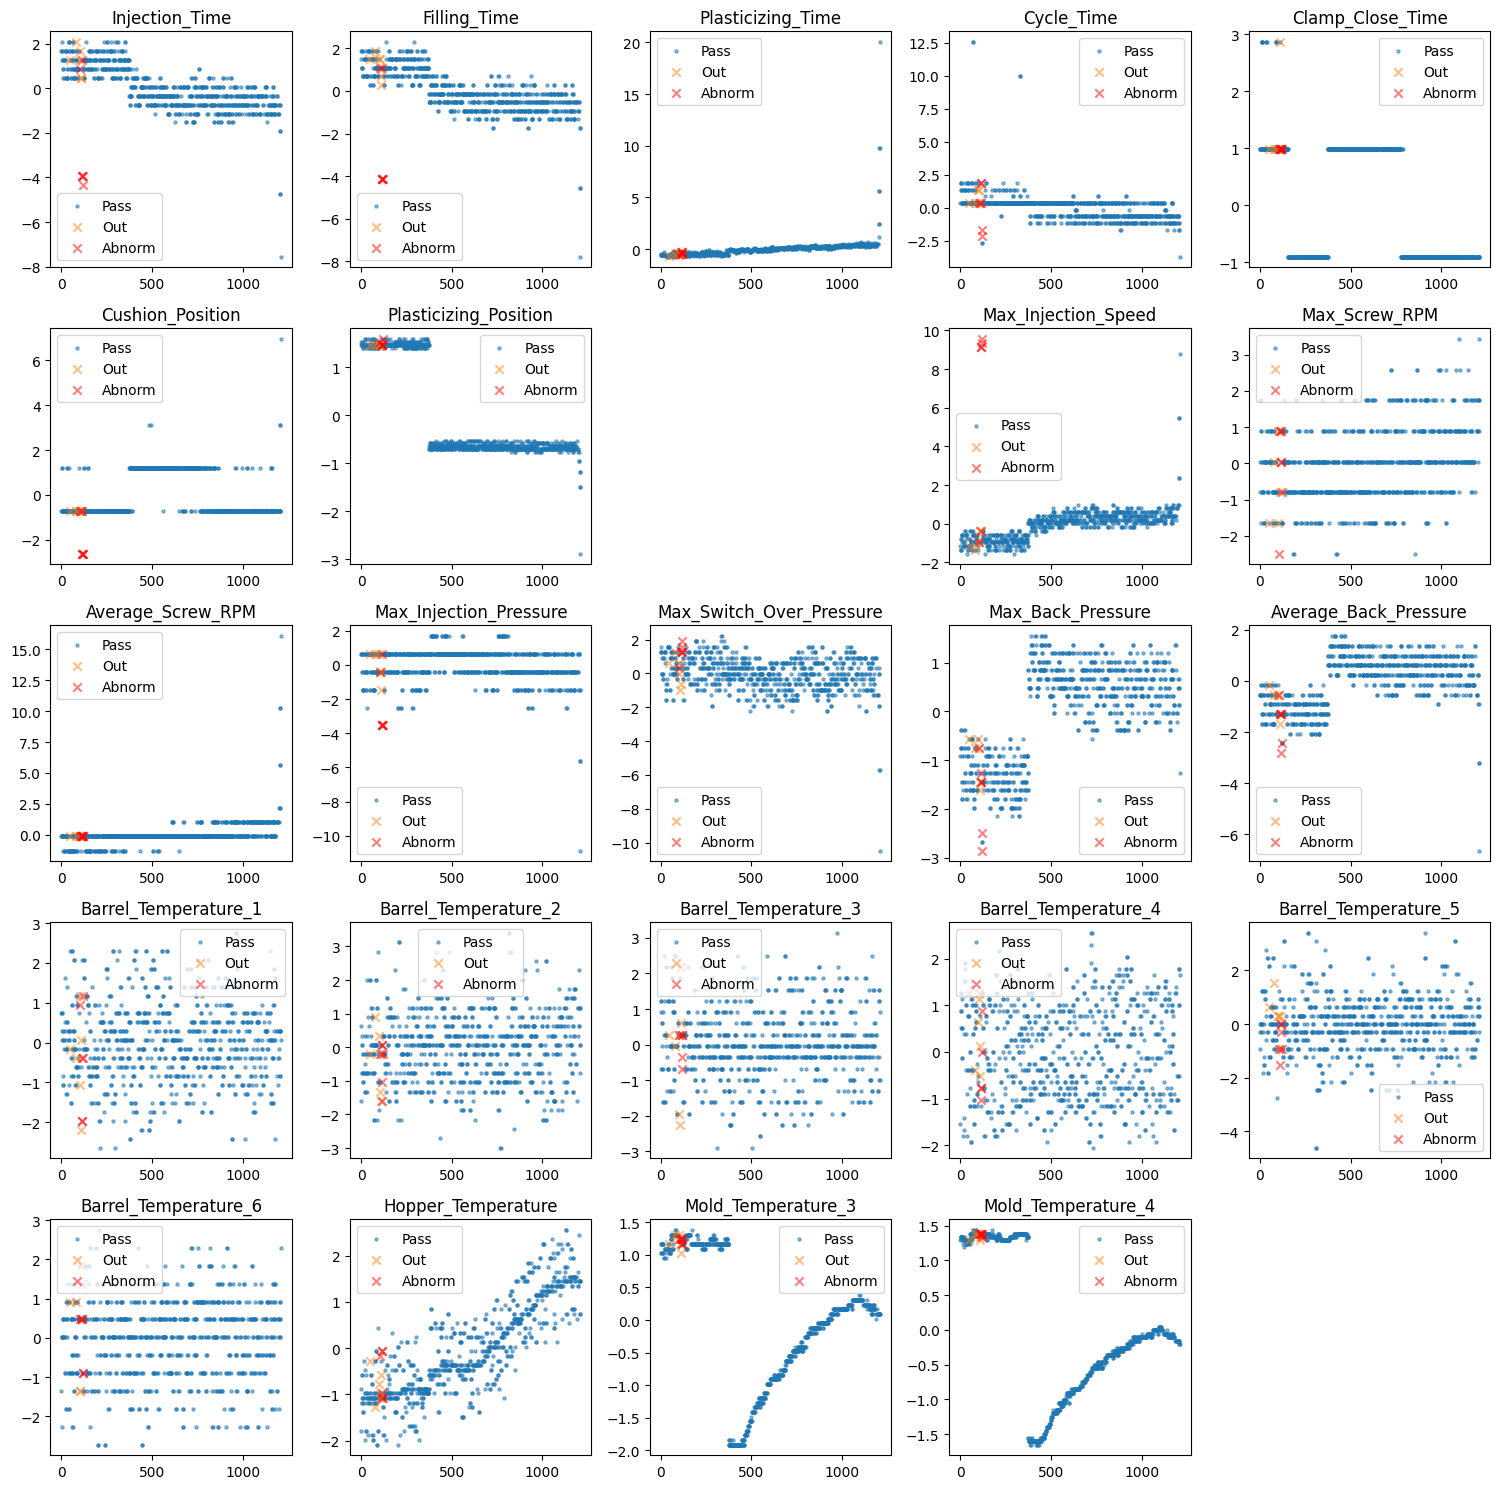

In [92]:
cond_normal = (tr_from_labeled_cn7['PassOrFail']==0)
cond_abnormal = (tr_from_labeled_cn7['PassOrFail']==1)
cond1 = (tr_from_labeled_cn7['duplicated_outliers']==0)
cond2 = (tr_from_labeled_cn7['duplicated_outliers']==1)

plt.figure(figsize=(15, 15))

for index, value in enumerate(tr_from_labeled_cn7.columns):
    if value == 'PassOrFail' or value == 'duplicated_outliers' or value=='Clamp_Open_Position':
        continue
    ax = plt.subplot(5, 5, index + 1)
    ax.scatter(tr_from_labeled_cn7[cond_normal & cond1].index, tr_from_labeled_cn7[cond_normal & cond1][value], alpha=0.5, label='Pass', s=5) # 정상
    ax.scatter(tr_from_labeled_cn7[cond_normal & cond2].index, tr_from_labeled_cn7[cond_normal & cond2][value], marker='x', alpha=0.5, label='Out') # 중복 값 이상치 (feature 값은 동일하지만 target 값이 다른 행)
    ax.scatter(tr_from_labeled_cn7[cond_abnormal & cond1].index, tr_from_labeled_cn7[cond_abnormal & cond1][value], marker='x', alpha=0.5, label='Abnorm', c='red') # 순수 불량
    plt.title(value)
    plt.legend()

plt.tight_layout()

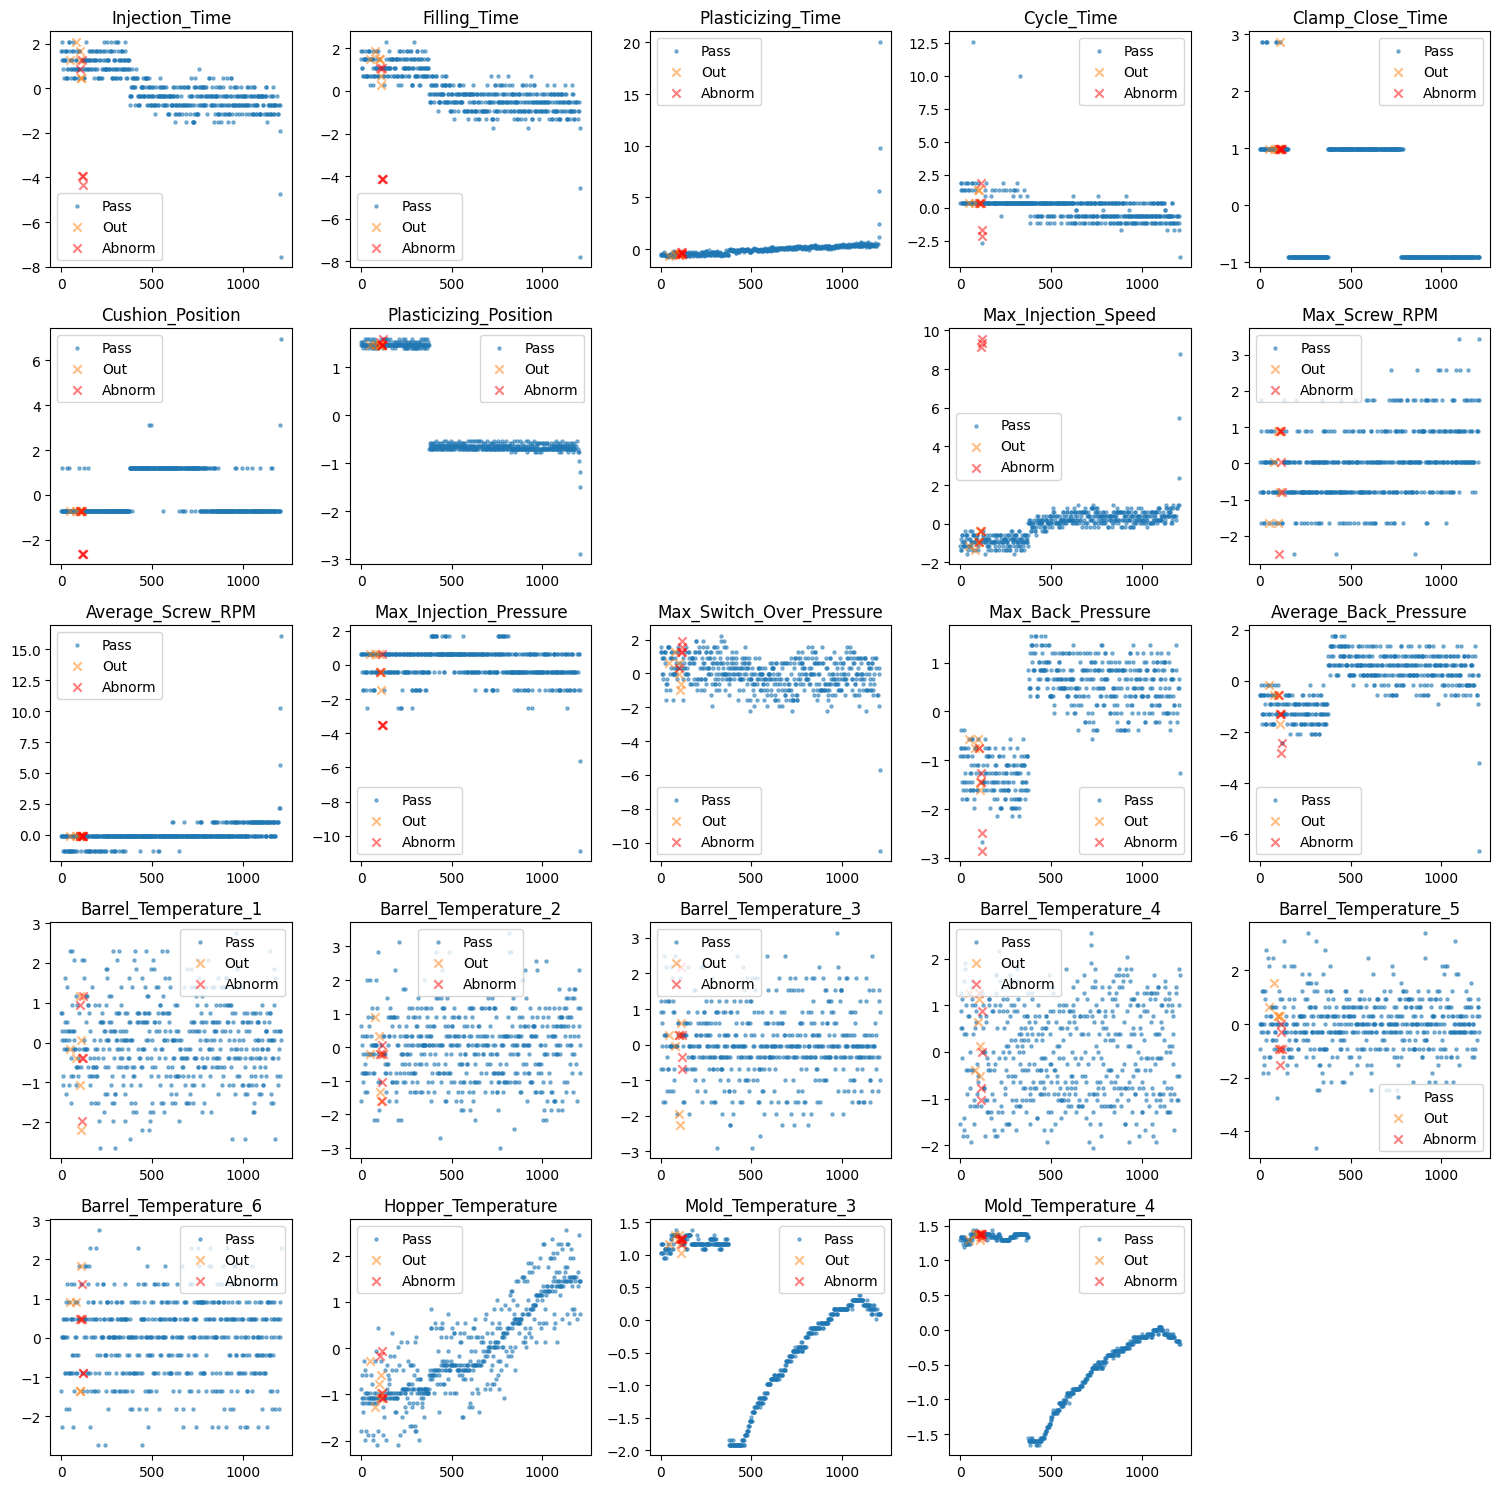

In [93]:
# 단순 중복 값 drop 후 시각화
without_duplicated_cn7 = tr_from_labeled_cn7.drop_duplicates(keep='first')

cond_normal = (without_duplicated_cn7['PassOrFail']==0)
cond_abnormal = (without_duplicated_cn7['PassOrFail']==1)
cond1 = (without_duplicated_cn7['duplicated_outliers']==0)
cond2 = (without_duplicated_cn7['duplicated_outliers']==1)

plt.figure(figsize=(15, 15))

for index, value in enumerate(without_duplicated_cn7.columns):
    if value == 'PassOrFail' or value == 'duplicated_outliers' or value=='Clamp_Open_Position':
        continue
    ax = plt.subplot(5, 5, index + 1)
    ax.scatter(without_duplicated_cn7[cond_normal & cond1].index, without_duplicated_cn7[cond_normal & cond1][value], alpha=0.5, label='Pass', s=5) # 정상
    ax.scatter(without_duplicated_cn7[cond_normal & cond2].index, without_duplicated_cn7[cond_normal & cond2][value], marker='x', alpha=0.5, label='Out') # 중복 값 이상치 (feature 값은 동일하지만 target 값이 다른 행)
    ax.scatter(without_duplicated_cn7[cond_abnormal & cond1].index, without_duplicated_cn7[cond_abnormal & cond1][value], marker='x', alpha=0.5, label='Abnorm', c='red') # 순수 불량
    plt.title(value)
    plt.legend()

plt.tight_layout()

In [96]:
without_duplicated_cn7[~(cond_normal & cond2)].shape

(548, 26)

In [94]:
print(unlabeled_cn7.duplicated().sum(), unlabeled_cn7.duplicated(keep=False).sum())
print(unlabeled_cn7.shape)

6468 12936
(35239, 24)


In [95]:
without_duplicated_unlabeled_cn7 = unlabeled_cn7.drop_duplicates(keep='first')
print(without_duplicated_cn7.shape)
print(without_duplicated_cn7['PassOrFail'].value_counts())
print(without_duplicated_unlabeled_cn7.shape)

(554, 26)
PassOrFail
0    543
1     11
Name: count, dtype: int64
(28771, 24)


In [ ]:
# labeled는 지금 split 후 중복 및 이상치 제거 -> 저장한 상태!!!!
# 이래도 되는지 재확인 필요
without_duplicated_cn7[~(cond_normal & cond2)].to_csv('../data/1. 사출성형기 AI 데이터셋/moldset_labeled_cn7_without_duplicated.csv', index=False)
without_duplicated_unlabeled_cn7.to_csv('../data/1. 사출성형기 AI 데이터셋/moldset_unlabeled_cn7_without_duplicated.csv', index=False)

---

In [110]:
# 재확인
print(labeled_cn7.shape)
print(set(labeled_cn7.index) - set(X_with_label_cn7.index)) # test set에 포함된 index가 labeled_cn7에는 존재하지 않음 (정상)
print(len(set(labeled_cn7.index) - set(X_with_label_cn7.index)), X_test_cn7.shape[0])

duplicated_indices = labeled_cn7.duplicated(keep=False).index
print("Duplicated indices:", duplicated_indices)
#labeled_cn7.duplicated().sum()

(1211, 25)
{1, 8, 13, 14, 16, 17, 20, 21, 26, 32, 34, 36, 37, 38, 40, 45, 49, 54, 65, 89, 93, 95, 98, 104, 105, 111, 114, 118, 119, 128, 129, 132, 136, 138, 139, 140, 144, 147, 151, 160, 163, 164, 167, 168, 169, 171, 174, 176, 177, 178, 179, 183, 188, 192, 197, 203, 204, 206, 207, 208, 211, 214, 217, 218, 219, 222, 223, 224, 233, 236, 242, 243, 246, 247, 249, 258, 262, 263, 269, 270, 272, 279, 286, 293, 296, 299, 300, 304, 305, 310, 312, 314, 318, 320, 332, 334, 339, 342, 347, 354, 360, 362, 365, 381, 389, 391, 395, 396, 401, 402, 404, 408, 409, 414, 417, 418, 419, 420, 423, 431, 435, 436, 438, 454, 458, 469, 472, 476, 480, 483, 486, 489, 491, 493, 497, 501, 505, 506, 509, 513, 519, 520, 525, 526, 527, 528, 532, 534, 537, 541, 554, 557, 563, 567, 573, 579, 580, 581, 582, 586, 588, 594, 596, 603, 609, 617, 623, 625, 627, 629, 640, 641, 642, 644, 649, 655, 656, 657, 658, 659, 662, 663, 664, 665, 668, 675, 676, 679, 680, 686, 689, 697, 698, 700, 702, 703, 704, 715, 716, 719, 722, 726, 727

In [116]:
labeled_cn7[labeled_cn7.duplicated(keep=False)]

,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
1,0,2.080358,1.894372,-0.527100,1.886261,0.978580,-0.711164,1.471608,0.0,-1.347095,...,-0.533773,0.056153,0.622557,0.914107,0.504051,-0.915098,-2.263700,-0.874018,1.023094,1.337339
2,0,2.080358,1.894372,-0.527100,1.886261,0.978580,-0.711164,1.471608,0.0,-1.347095,...,-0.533773,0.056153,0.622557,0.914107,0.504051,-0.915098,-2.263700,-0.874018,1.023094,1.337339
3,0,1.679123,1.894372,-0.527100,1.377857,0.978580,1.202502,1.471608,0.0,-1.347095,...,-0.533773,0.729073,-0.765355,1.231418,0.886706,-0.299626,0.013158,-1.176164,1.166162,1.337339
4,0,1.679123,1.894372,-0.527100,1.377857,0.978580,1.202502,1.471608,0.0,-1.347095,...,-0.533773,0.729073,-0.765355,1.231418,0.886706,-0.299626,0.013158,-1.176164,1.166162,1.337339
5,0,1.277888,1.088442,-0.576184,1.886261,0.978580,-0.711164,1.471608,0.0,-0.763018,...,-0.152634,0.280414,0.067358,0.596893,1.269321,0.008133,0.013158,-0.571865,1.166162,1.337339
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1206,0,-1.931915,-1.732320,5.608208,-1.164166,-0.902466,-0.711164,-1.185844,0.0,2.352070,...,-0.914898,0.280414,0.067358,1.548728,1.014257,0.623605,0.923887,0.737456,0.093154,-0.155625
1207,0,-4.740484,-4.553063,9.829303,-1.672571,-0.902466,3.116169,-1.487849,0.0,5.467151,...,-3.201688,-0.841164,1.177755,-0.989563,1.779489,0.315892,0.013158,1.442471,0.093154,-0.205391
1208,0,-4.740484,-4.553063,9.829303,-1.672571,-0.902466,3.116169,-1.487849,0.0,5.467151,...,-3.201688,-0.841164,1.177755,-0.989563,1.779489,0.315892,0.013158,1.442471,0.093154,-0.205391
1209,0,-7.549091,-7.776799,20.038456,-3.706092,-0.902466,6.943503,-2.876962,0.0,8.776929,...,-6.631852,0.056153,-0.765355,0.914107,1.651976,-0.299626,2.290016,1.442471,0.093154,-0.205391


#### (⚠️무시) RG3

In [73]:
print(tr_from_labeled_rg3.shape)
print(tr_from_labeled_rg3['PassOrFail'].value_counts())

(827, 26)
PassOrFail
0    810
1     17
Name: count, dtype: int64


In [74]:
print(X_with_label_rg3.duplicated().sum())      # feature 값만 동일한 행의 개수 (285)
print(tr_from_labeled_rg3.duplicated().sum())   # feature 값과 target 값까지 동일한 행의 개수 (274)

print(X_with_label_rg3.duplicated(keep=False).sum())      # feature 값만 동일한 행의 개수 (570)
print(tr_from_labeled_rg3.duplicated(keep=False).sum())   # feature 값과 target 값까지 동일한 행의 개수 (548)


285
274
570
548


In [75]:
duplicated_features = set(np.where(X_with_label_rg3.duplicated(keep=False)==True)[0])
duplicated_all = set(np.where(tr_from_labeled_rg3.duplicated(keep=False)==True)[0])
duplicated_outliers = duplicated_features - duplicated_all  # feature 값은 동일하지만 target 값이 다른 행의 index (outliers)

tr_from_labeled_rg3.iloc[list(duplicated_outliers)].sort_index()

,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,...,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4,PassOrFail,duplicated_outliers
1381,-0.029099,-1.192531,0.855360,0.249511,-0.386790,1.277707,0.588367,0.0,0.617645,-0.665752,...,0.230835,-0.002081,0.778986,-0.030765,0.143005,0.386588,-0.823555,-0.969082,1,1
1382,-0.029099,-1.192531,0.855360,0.249511,-0.386790,1.277707,0.588367,0.0,0.617645,-0.665752,...,0.230835,-0.002081,0.778986,-0.030765,0.143005,0.386588,-0.823555,-0.969082,0,1
1515,-0.029099,0.838552,1.528778,0.249511,1.033078,0.480326,-0.974521,0.0,0.617645,-0.665752,...,1.442567,-0.002081,0.632729,-0.344258,0.143005,0.589944,-0.538588,-0.483514,1,1
1516,-0.029099,0.838552,1.528778,0.249511,1.033078,0.480326,-0.974521,0.0,0.617645,-0.665752,...,1.442567,-0.002081,0.632729,-0.344258,0.143005,0.589944,-0.538588,-0.483514,0,1
1533,-0.029099,0.838552,0.630880,-0.846822,1.033078,0.480326,-0.192928,0.0,0.617645,-0.665752,...,-0.980897,0.305246,1.802734,0.282727,0.640193,0.691629,-0.253624,-0.362122,1,1
1534,-0.029099,0.838552,0.630880,-0.846822,1.033078,0.480326,-0.192928,0.0,0.617645,-0.665752,...,-0.980897,0.305246,1.802734,0.282727,0.640193,0.691629,-0.253624,-0.362122,0,1
1617,-0.029099,-1.192531,0.855360,0.249511,1.033078,1.277707,-0.974521,0.0,1.402554,2.019970,...,-1.223184,0.305246,-1.999704,2.163589,0.640193,-0.426850,0.173825,0.002053,0,1
1618,-0.029099,-1.192531,0.855360,0.249511,1.033078,1.277707,-0.974521,0.0,1.402554,2.019970,...,-1.223184,0.305246,-1.999704,2.163589,0.640193,-0.426850,0.173825,0.002053,1,1
1621,-0.029099,0.838552,-0.491498,0.249511,1.033078,-0.317055,-0.974521,0.0,0.617645,-0.665752,...,-0.496175,-0.923971,0.194005,-0.657751,-0.354184,0.386588,0.031342,-0.240729,1,1
1622,-0.029099,0.838552,-0.491498,0.249511,1.033078,-0.317055,-0.974521,0.0,0.617645,-0.665752,...,-0.496175,-0.923971,0.194005,-0.657751,-0.354184,0.386588,0.031342,-0.240729,0,1


In [79]:
# 단순히 중복된 행
tr_from_labeled_rg3.iloc[list(duplicated_all)]['PassOrFail'].value_counts()

PassOrFail
0    548
Name: count, dtype: int64

In [77]:
duplicated_outliers_1 = tr_from_labeled_rg3.iloc[list(duplicated_outliers)][tr_from_labeled_rg3.iloc[list(duplicated_outliers)]['PassOrFail']==1]
duplicated_outliers_0 = tr_from_labeled_rg3.iloc[list(duplicated_outliers)][tr_from_labeled_rg3.iloc[list(duplicated_outliers)]['PassOrFail']==0]

tr_from_labeled_rg3['duplicated_outliers'] = 0
tr_from_labeled_rg3.loc[list(duplicated_outliers_1.index), 'duplicated_outliers'] = 1
tr_from_labeled_rg3.loc[list(duplicated_outliers_0.index), 'duplicated_outliers'] = 1


In [78]:
tr_from_labeled_rg3['duplicated_outliers'].value_counts()

duplicated_outliers
0    805
1     22
Name: count, dtype: int64

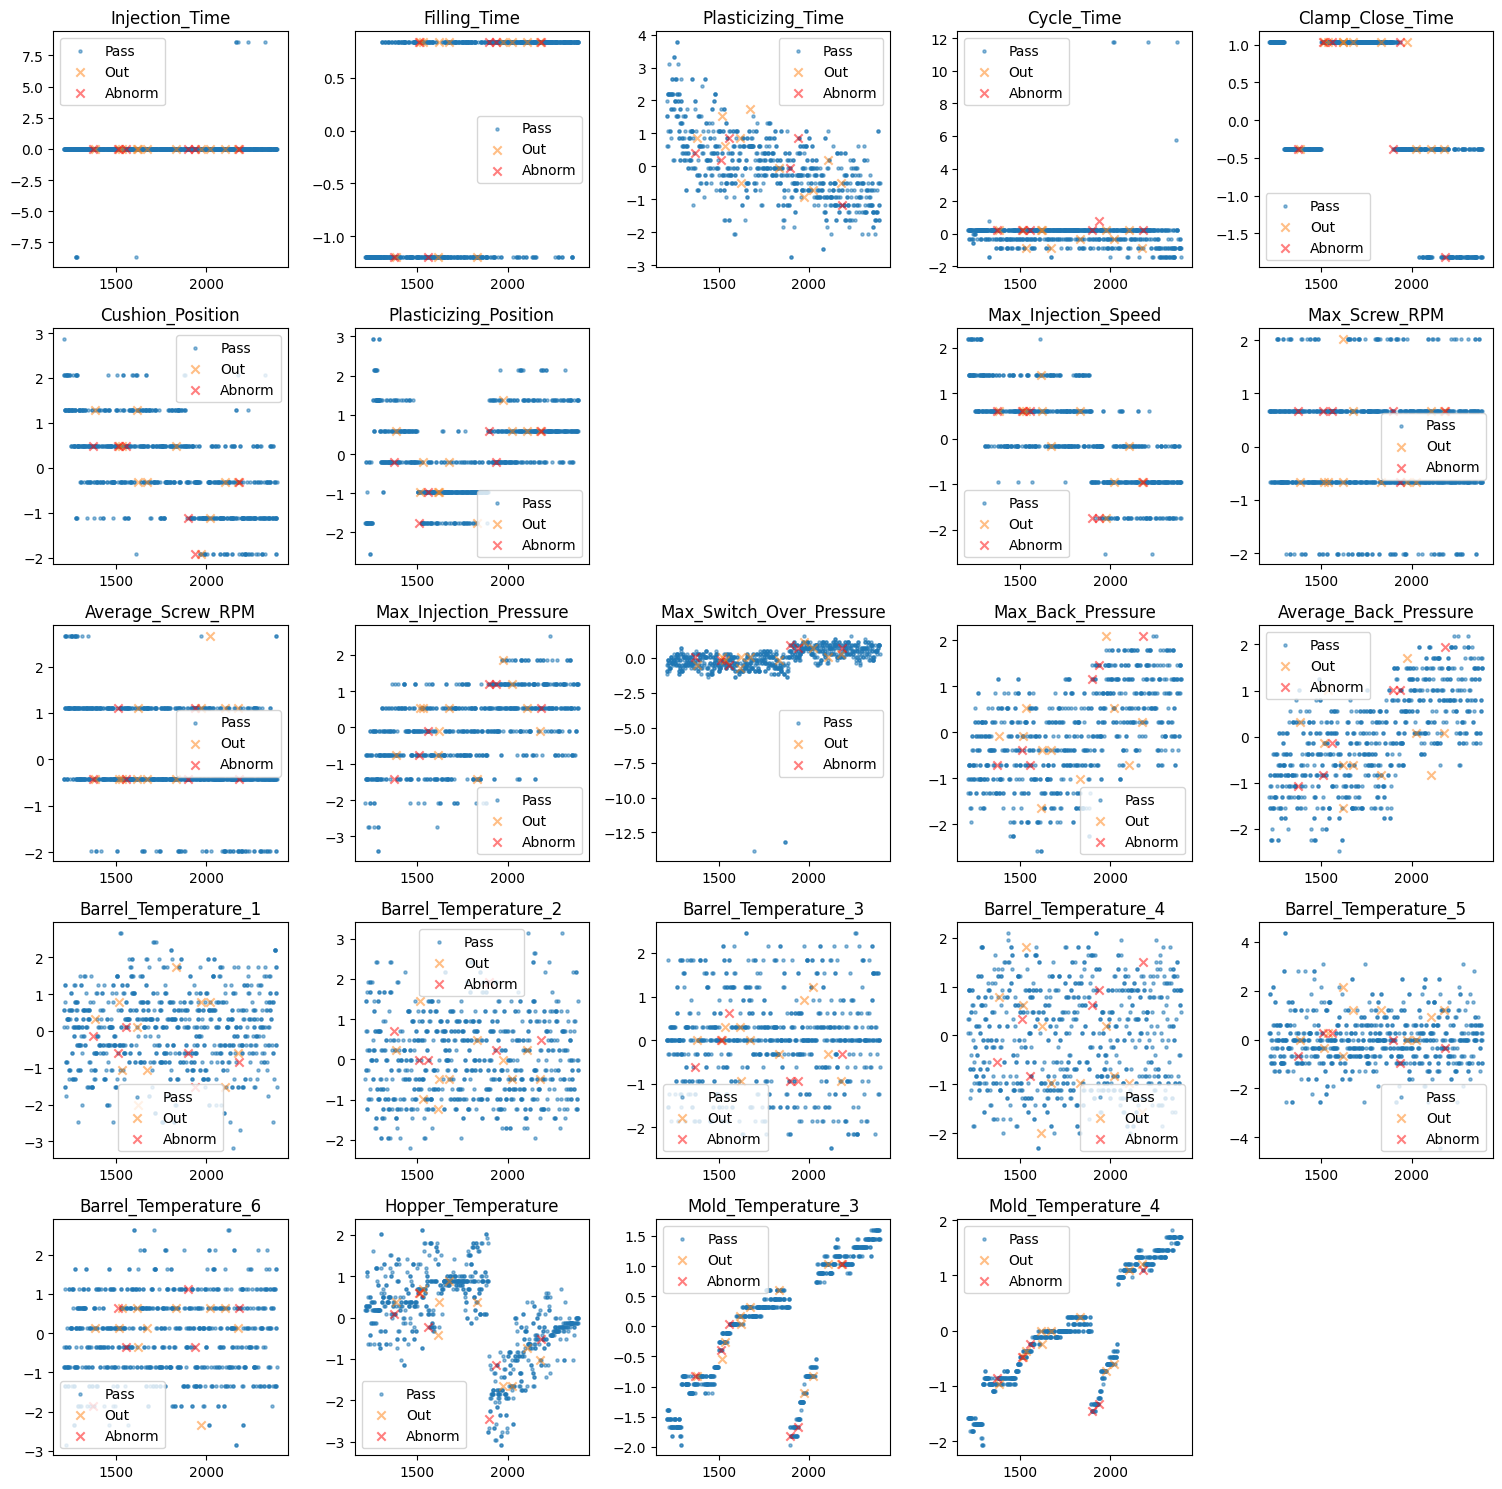

In [80]:
cond_normal = (tr_from_labeled_rg3['PassOrFail']==0)
cond_abnormal = (tr_from_labeled_rg3['PassOrFail']==1)
cond1 = (tr_from_labeled_rg3['duplicated_outliers']==0)
cond2 = (tr_from_labeled_rg3['duplicated_outliers']==1)

plt.figure(figsize=(15, 15))

for index, value in enumerate(tr_from_labeled_rg3.columns):
    if value == 'PassOrFail' or value == 'duplicated_outliers' or value=='Clamp_Open_Position':
        continue
    ax = plt.subplot(5, 5, index + 1)
    ax.scatter(tr_from_labeled_rg3[cond_normal & cond1].index, tr_from_labeled_rg3[cond_normal & cond1][value], alpha=0.5, label='Pass', s=5) # 정상
    ax.scatter(tr_from_labeled_rg3[cond_normal & cond2].index, tr_from_labeled_rg3[cond_normal & cond2][value], marker='x', alpha=0.5, label='Out') # 중복 값 이상치 (feature 값은 동일하지만 target 값이 다른 행)
    ax.scatter(tr_from_labeled_rg3[cond_abnormal & cond1].index, tr_from_labeled_rg3[cond_abnormal & cond1][value], marker='x', alpha=0.5, label='Abnorm', c='red') # 순수 불량
    plt.title(value)
    plt.legend()

plt.tight_layout()

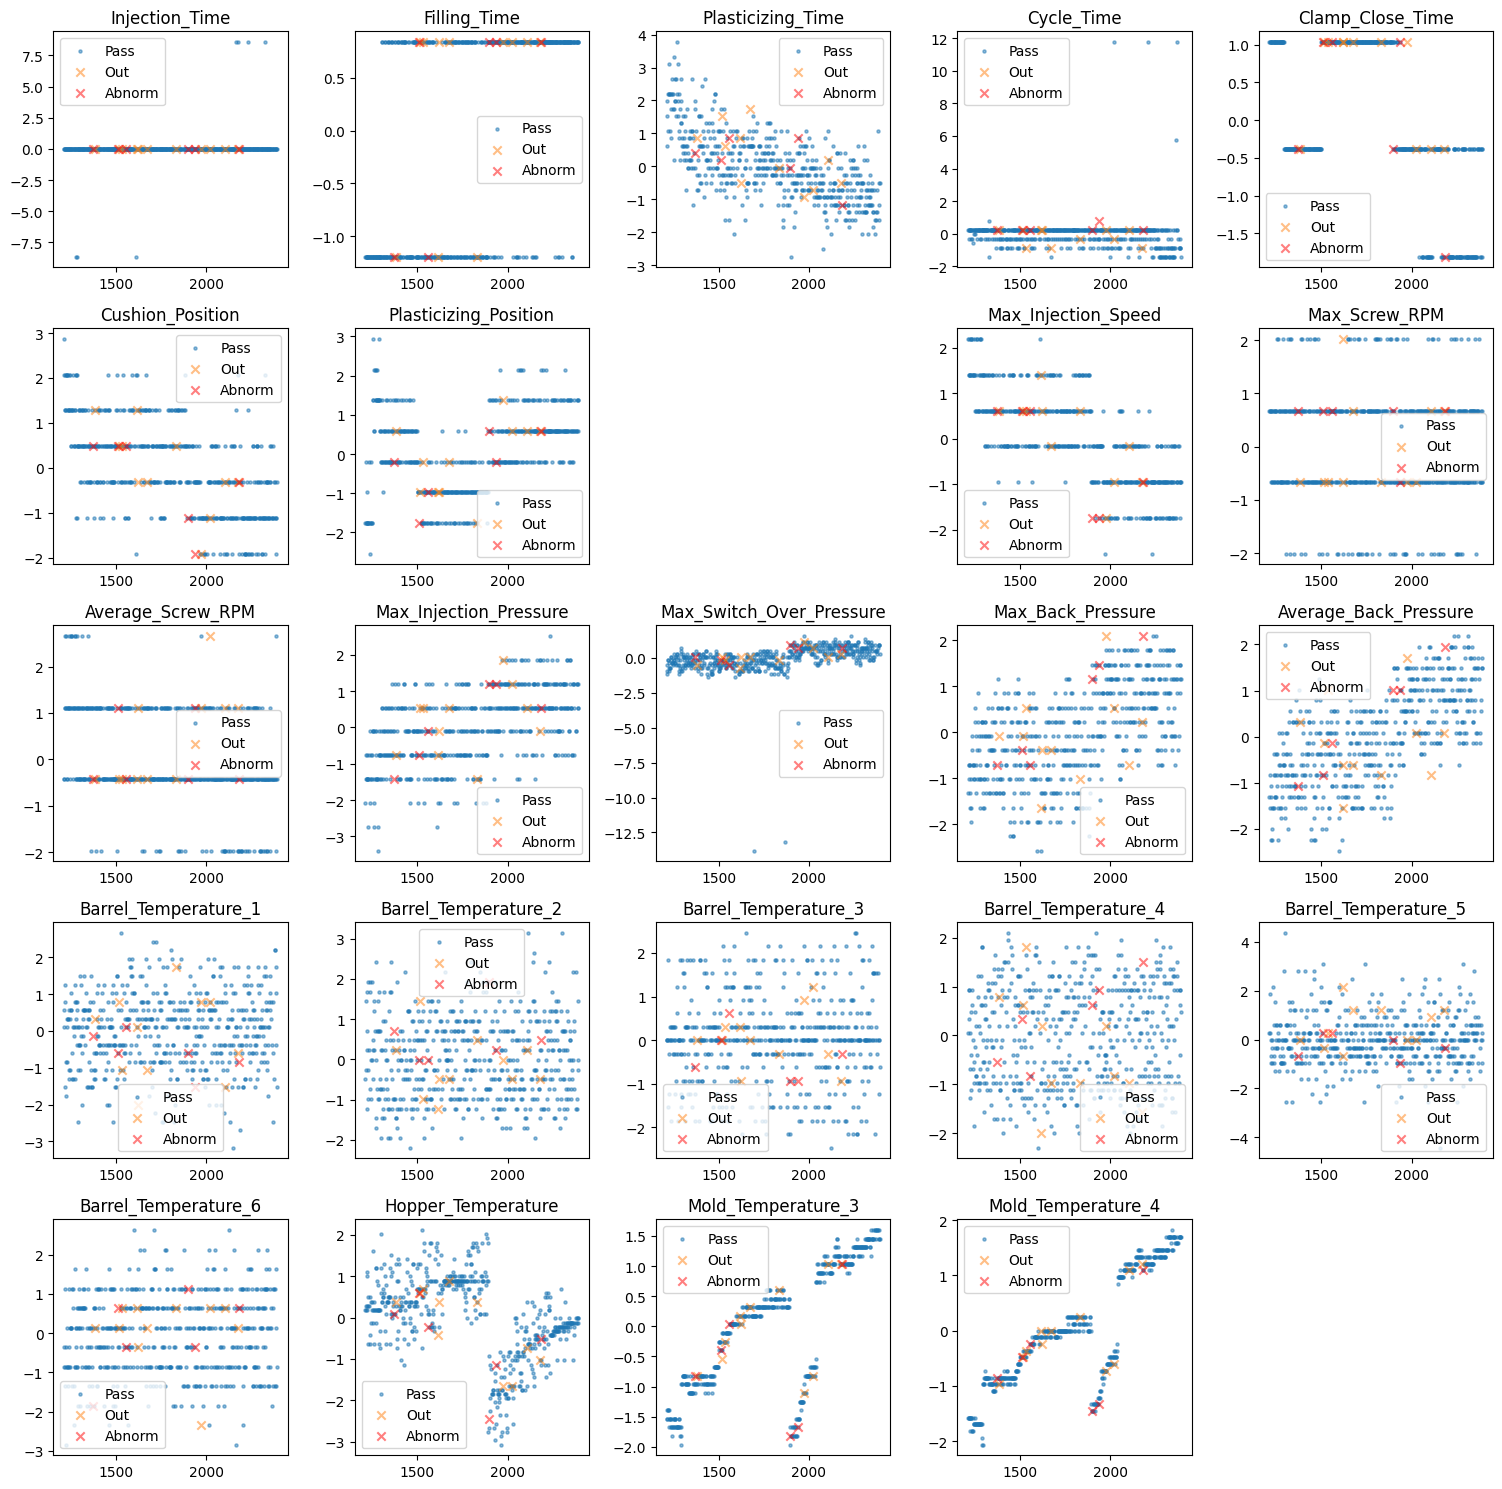

In [81]:
# 단순 중복 값 drop 후 시각화
without_duplicated_rg3 = tr_from_labeled_rg3.drop_duplicates(keep='first')

cond_normal = (without_duplicated_rg3['PassOrFail']==0)
cond_abnormal = (without_duplicated_rg3['PassOrFail']==1)
cond1 = (without_duplicated_rg3['duplicated_outliers']==0)
cond2 = (without_duplicated_rg3['duplicated_outliers']==1)

plt.figure(figsize=(15, 15))

for index, value in enumerate(without_duplicated_rg3.columns):
    if value == 'PassOrFail' or value == 'duplicated_outliers' or value=='Clamp_Open_Position':
        continue
    ax = plt.subplot(5, 5, index + 1)
    ax.scatter(without_duplicated_rg3[cond_normal & cond1].index, without_duplicated_rg3[cond_normal & cond1][value], alpha=0.5, label='Pass', s=5) # 정상
    ax.scatter(without_duplicated_rg3[cond_normal & cond2].index, without_duplicated_rg3[cond_normal & cond2][value], marker='x', alpha=0.5, label='Out') # 중복 값 이상치 (feature 값은 동일하지만 target 값이 다른 행)
    ax.scatter(without_duplicated_rg3[cond_abnormal & cond1].index, without_duplicated_rg3[cond_abnormal & cond1][value], marker='x', alpha=0.5, label='Abnorm', c='red') # 순수 불량
    plt.title(value)
    plt.legend()

plt.tight_layout()

In [85]:
without_duplicated_rg3[~(cond_normal & cond2)].shape

(542, 26)

In [82]:
print(unlabeled_rg3.duplicated().sum(), unlabeled_rg3.duplicated(keep=False).sum())
print(unlabeled_rg3.shape)

6234 12468
(35941, 24)


In [83]:
without_duplicated_unlabeled_rg3 = unlabeled_rg3.drop_duplicates(keep='first')
print(without_duplicated_rg3.shape)
print(without_duplicated_rg3['PassOrFail'].value_counts())
print(without_duplicated_unlabeled_rg3.shape)

(553, 26)
PassOrFail
0    536
1     17
Name: count, dtype: int64
(29707, 24)


In [86]:
without_duplicated_rg3[~(cond_normal & cond2)].to_csv('../data/1. 사출성형기 AI 데이터셋/moldset_labeled_rg3_without_duplicated.csv', index=False)
without_duplicated_unlabeled_rg3.to_csv('../data/1. 사출성형기 AI 데이터셋/moldset_unlabeled_rg3_without_duplicated.csv', index=False)

In [104]:
test_set_rg3 = pd.concat([X_test_rg3, y_test_rg3], axis=1)
print(X_test_rg3.duplicated(keep=False).sum())
print(test_set_rg3.duplicated(keep=False).sum())

98
94


### Problem 2. Clamp Open Position

Clamp Open Position 값이 정상적으로 입력된 unlabeled 데이터셋을 이용하여 labeled의 변수값을 채우는 전략

[접두사]
- `COP_`

[사용 모델]
- `pycaret`으로 best model 결정
- 선정된 모델 : 

In [78]:
from pycaret.regression import *

#### CN7

In [79]:
# load data
prc_labeled_cn7 =pd.read_csv('../data/1. 사출성형기 AI 데이터셋/processed_moldset_labeled_cn7.csv')
prc_unlabeled_cn7 =pd.read_csv('../data/1. 사출성형기 AI 데이터셋/processed_moldset_unlabeled_cn7.csv')

print(prc_labeled_cn7.shape)
print(prc_unlabeled_cn7.shape)

(617, 26)
(28771, 25)


In [83]:
target_col = 'Clamp_Open_Position'
reg = setup(prc_unlabeled_cn7, target=target_col,normalize=True, normalize_method='robust',
            train_size=0.8,session_id=777, polynomial_features=True, #remove_outliers=True, profile=True,
            remove_multicollinearity=True)

,Description,Value
0,Session id,777
1,Target,Clamp_Open_Position
2,Target type,Regression
3,Original data shape,"(28771, 25)"
4,Transformed data shape,"(28771, 57)"
5,Transformed train set shape,"(23016, 57)"
6,Transformed test set shape,"(5755, 57)"
7,Numeric features,24
8,Preprocess,True
9,Imputation type,simple


In [84]:
best_3 = compare_models(sort='RMSE', n_select=3) #RMSE 기준 상위 3개 모델 추출 

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
dt,Decision Tree Regressor,0.0005,0.0007,0.0096,0.9993,0.0032,0.0008,0.3990
gbr,Gradient Boosting Regressor,0.0007,0.0011,0.0122,0.9989,0.0038,0.0011,1.5340
rf,Random Forest Regressor,0.0006,0.0010,0.0127,0.9990,0.0044,0.0007,2.5240
et,Extra Trees Regressor,0.0006,0.0010,0.0137,0.9990,0.0052,0.0008,1.1800
lightgbm,Light Gradient Boosting Machine,0.0025,0.0013,0.0256,0.9987,0.0091,0.0034,0.7830
ridge,Ridge Regression,0.0146,0.0010,0.0278,0.9990,0.0134,0.0297,0.3390
knn,K Neighbors Regressor,0.0011,0.0021,0.0287,0.9979,0.0062,0.0012,0.3940
ada,AdaBoost Regressor,0.0136,0.0013,0.0293,0.9988,0.0130,0.0230,0.6350
br,Bayesian Ridge,0.0147,0.0050,0.0459,0.9950,0.0159,0.0294,0.3640
lr,Linear Regression,0.0147,0.0052,0.0464,0.9949,0.0157,0.0294,0.6280


In [85]:
best_model = best_3[0]
tuned_model = tune_model(best_model, optimize='RMSE', n_iter=10, choose_better=True)
final_model = finalize_model(tuned_model)
save_model(final_model, model_name='COP_model_cn7')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.0007,0.0000,0.0017,1.0000,0.0011,0.0015
1,0.0022,0.0075,0.0863,0.9926,0.0278,0.0014
2,0.0011,0.0005,0.0214,0.9995,0.0107,0.0024
3,0.0011,0.0005,0.0214,0.9996,0.0107,0.0023
4,0.0007,0.0000,0.0017,1.0000,0.0011,0.0015
5,0.0008,0.0000,0.0058,1.0000,0.0016,0.0015
6,0.0012,0.0005,0.0214,0.9996,0.0107,0.0024
7,0.0007,0.0000,0.0019,1.0000,0.0012,0.0016
8,0.0016,0.0009,0.0302,0.9991,0.0151,0.0031


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['Unnamed: 0', 'Injection_Time',
                                              'Filling_Time',
                                              'Plasticizing_Time', 'Cycle_Time',
                                              'Clamp_Close_Time',
                                              'Cushion_Position',
                                              'Plasticizing_Position',
                                              'Max_Injection_Speed',
                                              'Max_Screw_RPM',
                                              'Average_Screw_RPM',
                                              'Max_Injection_Pressure',
                                              'Max_Switch_Over_Pressure',
                                              'Max_Ba...
                  TransformerWrapper(transformer=PolynomialFeatures(include_bias=False))),
    

In [89]:
pred = predict_model(final_model, prc_labeled_cn7)
prc_labeled_cn7['Predicted_COP'] = pred['prediction_label']
prc_labeled_cn7['Predicted_COP']

0     -4.626025
1     -4.626025
2      0.861854
3     -0.226463
4      0.861854
         ...   
612   -0.226463
613   -0.226463
614   -4.626025
615   -4.626025
616   -4.626025
Name: Predicted_COP, Length: 617, dtype: float64

In [91]:
# 기존의 Clamp_Open_Position 값을 예측치로 대치 후 저장
prc_labeled_cn7['Clamp_Open_Position'] = prc_labeled_cn7['Predicted_COP']
prc_labeled_cn7.drop(columns='Predicted_COP', inplace=True)
prc_labeled_cn7.to_csv('../data/1. 사출성형기 AI 데이터셋/processed2_moldset_labeled_cn7.csv')

#### RG3

In [92]:
# load data
prc_labeled_rg3 =pd.read_csv('../data/1. 사출성형기 AI 데이터셋/processed_moldset_labeled_rg3.csv')
prc_unlabeled_rg3 =pd.read_csv('../data/1. 사출성형기 AI 데이터셋/processed_moldset_unlabeled_rg3.csv')

print(prc_labeled_rg3.shape)
print(prc_unlabeled_rg3.shape)

(616, 26)
(29707, 25)


In [93]:
target_col = 'Clamp_Open_Position'
reg = setup(prc_unlabeled_rg3, target=target_col,normalize=True, normalize_method='robust',
            train_size=0.8,session_id=777, polynomial_features=True, #remove_outliers=True, profile=True,
            remove_multicollinearity=True)

,Description,Value
0,Session id,777
1,Target,Clamp_Open_Position
2,Target type,Regression
3,Original data shape,"(29707, 25)"
4,Transformed data shape,"(29707, 46)"
5,Transformed train set shape,"(23765, 46)"
6,Transformed test set shape,"(5942, 46)"
7,Numeric features,24
8,Preprocess,True
9,Imputation type,simple


In [94]:
best_3 = compare_models(sort='RMSE', n_select=3) #RMSE 기준 상위 3개 모델 추출 

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.0014,0.0015,0.0289,0.9986,0.0115,0.0013,1.0770
rf,Random Forest Regressor,0.0018,0.0021,0.0374,0.9980,0.0134,0.0016,3.2400
gbr,Gradient Boosting Regressor,0.0027,0.0022,0.0375,0.9979,0.0157,0.0028,1.7570
dt,Decision Tree Regressor,0.0012,0.0028,0.0404,0.9973,0.0077,0.0012,0.4490
lightgbm,Light Gradient Boosting Machine,0.0043,0.0025,0.0412,0.9976,0.0163,0.0047,0.7860
knn,K Neighbors Regressor,0.0034,0.0030,0.0469,0.9971,0.0190,0.0026,0.4500
ada,AdaBoost Regressor,0.0390,0.0032,0.0559,0.9969,0.0247,0.0399,0.8240
ridge,Ridge Regression,0.0186,0.1513,0.1758,0.8543,0.0232,0.0198,0.3510
br,Bayesian Ridge,0.0199,0.1794,0.1877,0.8272,0.0248,0.0217,0.3920
lr,Linear Regression,0.0200,0.1805,0.1882,0.8262,0.0249,0.0219,0.6790


In [97]:
best_model = best_3[0]
#tuned_model = tune_model(best_model, optimize='RMSE', n_iter=2, choose_better=True)
final_model = finalize_model(tuned_model)
save_model(final_model, model_name='COP_model_rg3')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['Unnamed: 0', 'Injection_Time',
                                              'Filling_Time',
                                              'Plasticizing_Time', 'Cycle_Time',
                                              'Clamp_Close_Time',
                                              'Cushion_Position',
                                              'Plasticizing_Position',
                                              'Max_Injection_Speed',
                                              'Max_Screw_RPM',
                                              'Average_Screw_RPM',
                                              'Max_Injection_Pressure',
                                              'Max_Switch_Over_Pressure',
                                              'Max_Ba...
                  TransformerWrapper(transformer=PolynomialFeatures(include_bias=False))),
    

In [98]:
pred = predict_model(final_model, prc_labeled_rg3)
prc_labeled_rg3['Predicted_COP'] = pred['prediction_label']
prc_labeled_rg3['Predicted_COP']

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Decision Tree Regressor,0.9182,0.9096,0.9537,0.0000,0.6554,nan


0      1.362091
1      1.362091
2      1.362091
3     -0.798458
4     -0.798458
         ...   
611   -0.639830
612   -0.798458
613   -0.798458
614   -0.798458
615   -0.798458
Name: Predicted_COP, Length: 616, dtype: float64

In [99]:
# 기존의 Clamp_Open_Position 값을 예측치로 대치 후 저장
prc_labeled_rg3['Clamp_Open_Position'] = prc_labeled_rg3['Predicted_COP']
prc_labeled_rg3.drop(columns='Predicted_COP', inplace=True)
prc_labeled_rg3.to_csv('../data/1. 사출성형기 AI 데이터셋/processed2_moldset_labeled_rg3.csv')

## Experiments

In [ ]:
import pandas as pd

display(pd.read_csv('../data/1. 사출성형기 AI 데이터셋/processed_moldset_unlabeled_rg3.csv',index_col=0).head())
display(pd.read_csv('../data/1. 사출성형기 AI 데이터셋/processed_moldset_labeled_rg3.csv',index_col=0).head())
pd.read_csv('../data/1. 사출성형기 AI 데이터셋/processed2_moldset_labeled_rg3.csv',index_col=0).head()

,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
119515,0.90919,1.662808,-1.131352,-1.174407,-1.262902,-1.314850,-1.026514,1.362091,-1.203070,-1.179145,...,-1.154268,-1.310547,-0.666957,-0.395393,0.088306,0.041839,0.945920,0.087427,-1.276966,-1.225083
119547,0.90919,1.662808,-1.131352,-1.174407,-1.262902,-1.314850,-1.026514,1.362091,-1.200666,-1.179145,...,-1.154268,-1.310547,-0.674680,-0.403577,0.078025,0.029691,0.925301,0.107476,-1.276966,-1.225083
119618,0.90919,1.662808,-1.147464,-1.174407,-1.262902,-1.315176,-1.026514,1.362091,-1.200666,-1.179145,...,-1.154268,-1.310547,-0.636064,-0.395393,0.078025,0.066135,0.904682,0.107476,-1.276966,-1.225083
119781,0.90919,1.662808,-1.131352,-1.174407,-1.262902,-1.314850,-1.026514,1.362091,-1.193454,-1.179145,...,-1.154268,-1.310547,-0.674680,-0.395393,0.067743,0.029691,0.863445,0.127524,-1.276966,-1.225083
120044,0.90919,1.662808,-1.131352,-1.174407,-1.262902,-1.314850,-1.026514,1.362091,-1.159797,-1.179145,...,-1.154268,-1.310547,-0.674680,-0.395393,0.088306,0.041839,0.945920,0.147573,-1.276966,-1.225083


,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
1211,0,-0.029099,-1.192531,1.977737,0.249511,1.033078,2.867608,-1.755816,0.0,2.187583,...,-1.306878,0.096629,-0.496175,-0.002081,0.047749,0.282727,-0.354184,0.183232,-1.393485,-1.576042
1213,0,-0.029099,-1.192531,1.528778,0.249511,1.033078,2.075089,-0.192928,0.0,2.187583,...,-0.841877,0.562844,1.442567,-0.002081,0.340262,1.850096,-0.851297,0.183232,-1.535968,-1.576042
1215,0,-0.029099,-1.192531,0.630880,-0.298708,1.033078,1.277707,-1.755816,0.0,1.402554,...,-1.539374,1.262095,-0.253813,-0.002081,0.925242,0.282727,-1.348485,0.284910,-1.535968,-1.576042
1217,0,-0.029099,-1.192531,2.202217,0.249511,1.033078,1.277707,-1.755816,0.0,1.402554,...,-1.074373,-1.535053,0.715557,-1.538626,0.925242,-0.657751,-0.851297,0.284910,-1.393485,-1.576042
1219,0,-0.029099,-1.192531,1.079840,0.249511,1.033078,2.075089,-1.755816,0.0,1.402554,...,-1.306878,0.795880,1.684928,1.841791,0.047749,-0.030765,1.137306,0.183232,-1.393485,-1.576042


,,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
,Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0,1211,0,-0.029099,-1.192531,1.977737,0.249511,1.033078,2.867608,-1.755816,1.362091,2.187583,...,-1.306878,0.096629,-0.496175,-0.002081,0.047749,0.282727,-0.354184,0.183232,-1.393485,-1.576042
1,1213,0,-0.029099,-1.192531,1.528778,0.249511,1.033078,2.075089,-0.192928,1.362091,2.187583,...,-0.841877,0.562844,1.442567,-0.002081,0.340262,1.850096,-0.851297,0.183232,-1.535968,-1.576042
2,1215,0,-0.029099,-1.192531,0.630880,-0.298708,1.033078,1.277707,-1.755816,1.362091,1.402554,...,-1.539374,1.262095,-0.253813,-0.002081,0.925242,0.282727,-1.348485,0.284910,-1.535968,-1.576042
3,1217,0,-0.029099,-1.192531,2.202217,0.249511,1.033078,1.277707,-1.755816,-0.798458,1.402554,...,-1.074373,-1.535053,0.715557,-1.538626,0.925242,-0.657751,-0.851297,0.284910,-1.393485,-1.576042
4,1219,0,-0.029099,-1.192531,1.079840,0.249511,1.033078,2.075089,-1.755816,-0.798458,1.402554,...,-1.306878,0.795880,1.684928,1.841791,0.047749,-0.030765,1.137306,0.183232,-1.393485,-1.576042


In [1]:
import sys; sys.path.append('../src')
from ssl_train import run_experiments

df = run_experiments(
    'rg3','processed2',
    prep_grid={
        'scaling': [None],
        'feature_selection': [None, ['corr', 'kbest']],
        'imbalance': ['class_weight', 'smote'],
    },
    models=['svc', 'rf', 'gnb'],
    ssl_methods=['self_training'],   # 지도 baseline(None) vs 준지도 비교
    n_iter={'default': 15, 'dnn': 6},
    log_path='../logs/experiment_log.csv',
)


===== [1/4] rg3/processed2 preprocessing: {'scaling': None, 'feature_selection': None, 'imbalance': 'class_weight'} =====
[rg3/processed2] model=svc | ssl=self_training | scaling=none | fs=none | imbalance=class_weight | outlier=none
    Accuracy=0.9622  Recall=0.7143  Precision=0.7692  F1=0.7407  ROC-AUC=0.9006  PR-AUC=0.8085
    confusion(tn/fp/fn/tp)=168/3/4/10  cv_f1=0.6719  n_features=24  fit_time=412.5s
    best_params={"kernel": "rbf", "gamma": 0.1, "C": 1}


KeyboardInterrupt: 

In [ ]:
# dnn은 따로 진행
df = run_experiments(
    'rg3','processed2',
    prep_grid={
        'scaling': [None],
        'feature_selection': [None, ['corr', 'kbest']],
        'imbalance': ['class_weight', 'smote'],
    },
    models=['dnn'],
    ssl_methods=['self_training'],   # 지도 baseline(None) vs 준지도 비교
    n_iter={'default': 15, 'dnn': 6},
    log_path='../logs/experiment_log.csv',
)